In [1]:
import os

notebook_path = os.path.abspath("")
source_folder = "src"
source_path = notebook_path[:notebook_path.find(source_folder) + len(source_folder)]

os.chdir(source_path)

In [2]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pymc_extras.prior import Prior

from pymc_marketing.mmm import MMM, GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.transformers import geometric_adstock, logistic_saturation

warnings.filterwarnings("ignore", category=FutureWarning)

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

/anaconda/envs/mkt-mix-modeling/lib/python3.13/site-packages/pymc_extras/model/marginal/graph_analysis.py:10: FutureWarning: `pytensor.graph.basic.io_toposort` was moved to `pytensor.graph.traversal.io_toposort`. Calling it from the old location will fail in a future release.
  from pytensor.graph.basic import io_toposort


# 1. Data

In [3]:
dt_prophet_holidays = pd.read_csv("data/03_primary/dt_prophet_holidays.csv")
dt_simulated_weekly = pd.read_csv("data/03_primary/dt_simulated_weekly.csv")

In [4]:
# Parameters
window_start = "2016-01-01"
window_end = "2018-12-31"
country = "DE"

# Sales
dt_simulated_weekly = dt_simulated_weekly.rename({"DATE":"ds"}, axis=1)
df_sales = dt_simulated_weekly[dt_simulated_weekly["ds"].between(window_start, window_end)].copy()
df_sales["ds"] = pd.to_datetime(df_sales["ds"], format="%Y-%m-%d")

df_sales["year"] = pd.to_datetime(df_sales["ds"]).dt.year
df_sales["month"] = pd.to_datetime(df_sales["ds"]).dt.month

# Holidays
df_holidays = dt_prophet_holidays[dt_prophet_holidays["ds"].between(window_start, window_end) & (dt_prophet_holidays["country"] == country)].copy()
df_holidays["ds"] = pd.to_datetime(df_holidays["ds"], format="%Y-%m-%d")
df_holidays["month"] = pd.to_datetime(df_holidays["ds"]).dt.month

df_holidays = df_holidays.groupby(["year", "month"],as_index=False).agg(holidays=("holiday","count"))

In [5]:
df_sales = df_sales.merge(df_holidays, on=["year", "month"], how="left").fillna(0)
df_sales["events"] = np.where(df_sales["events"] == "na", 0, 1)

In [6]:
# Processed data
channel_cols = ["tv_S", "ooh_S", "print_S", "search_S", "facebook_S"]
channel_cols.sort()

control_cols = ["newsletter", "competitor_sales_B", "events", "holidays"]

sales_col = "revenue"
date_col = "ds"

df_mmm = df_sales[[date_col, sales_col, *channel_cols, *control_cols]]

# 2. EDA

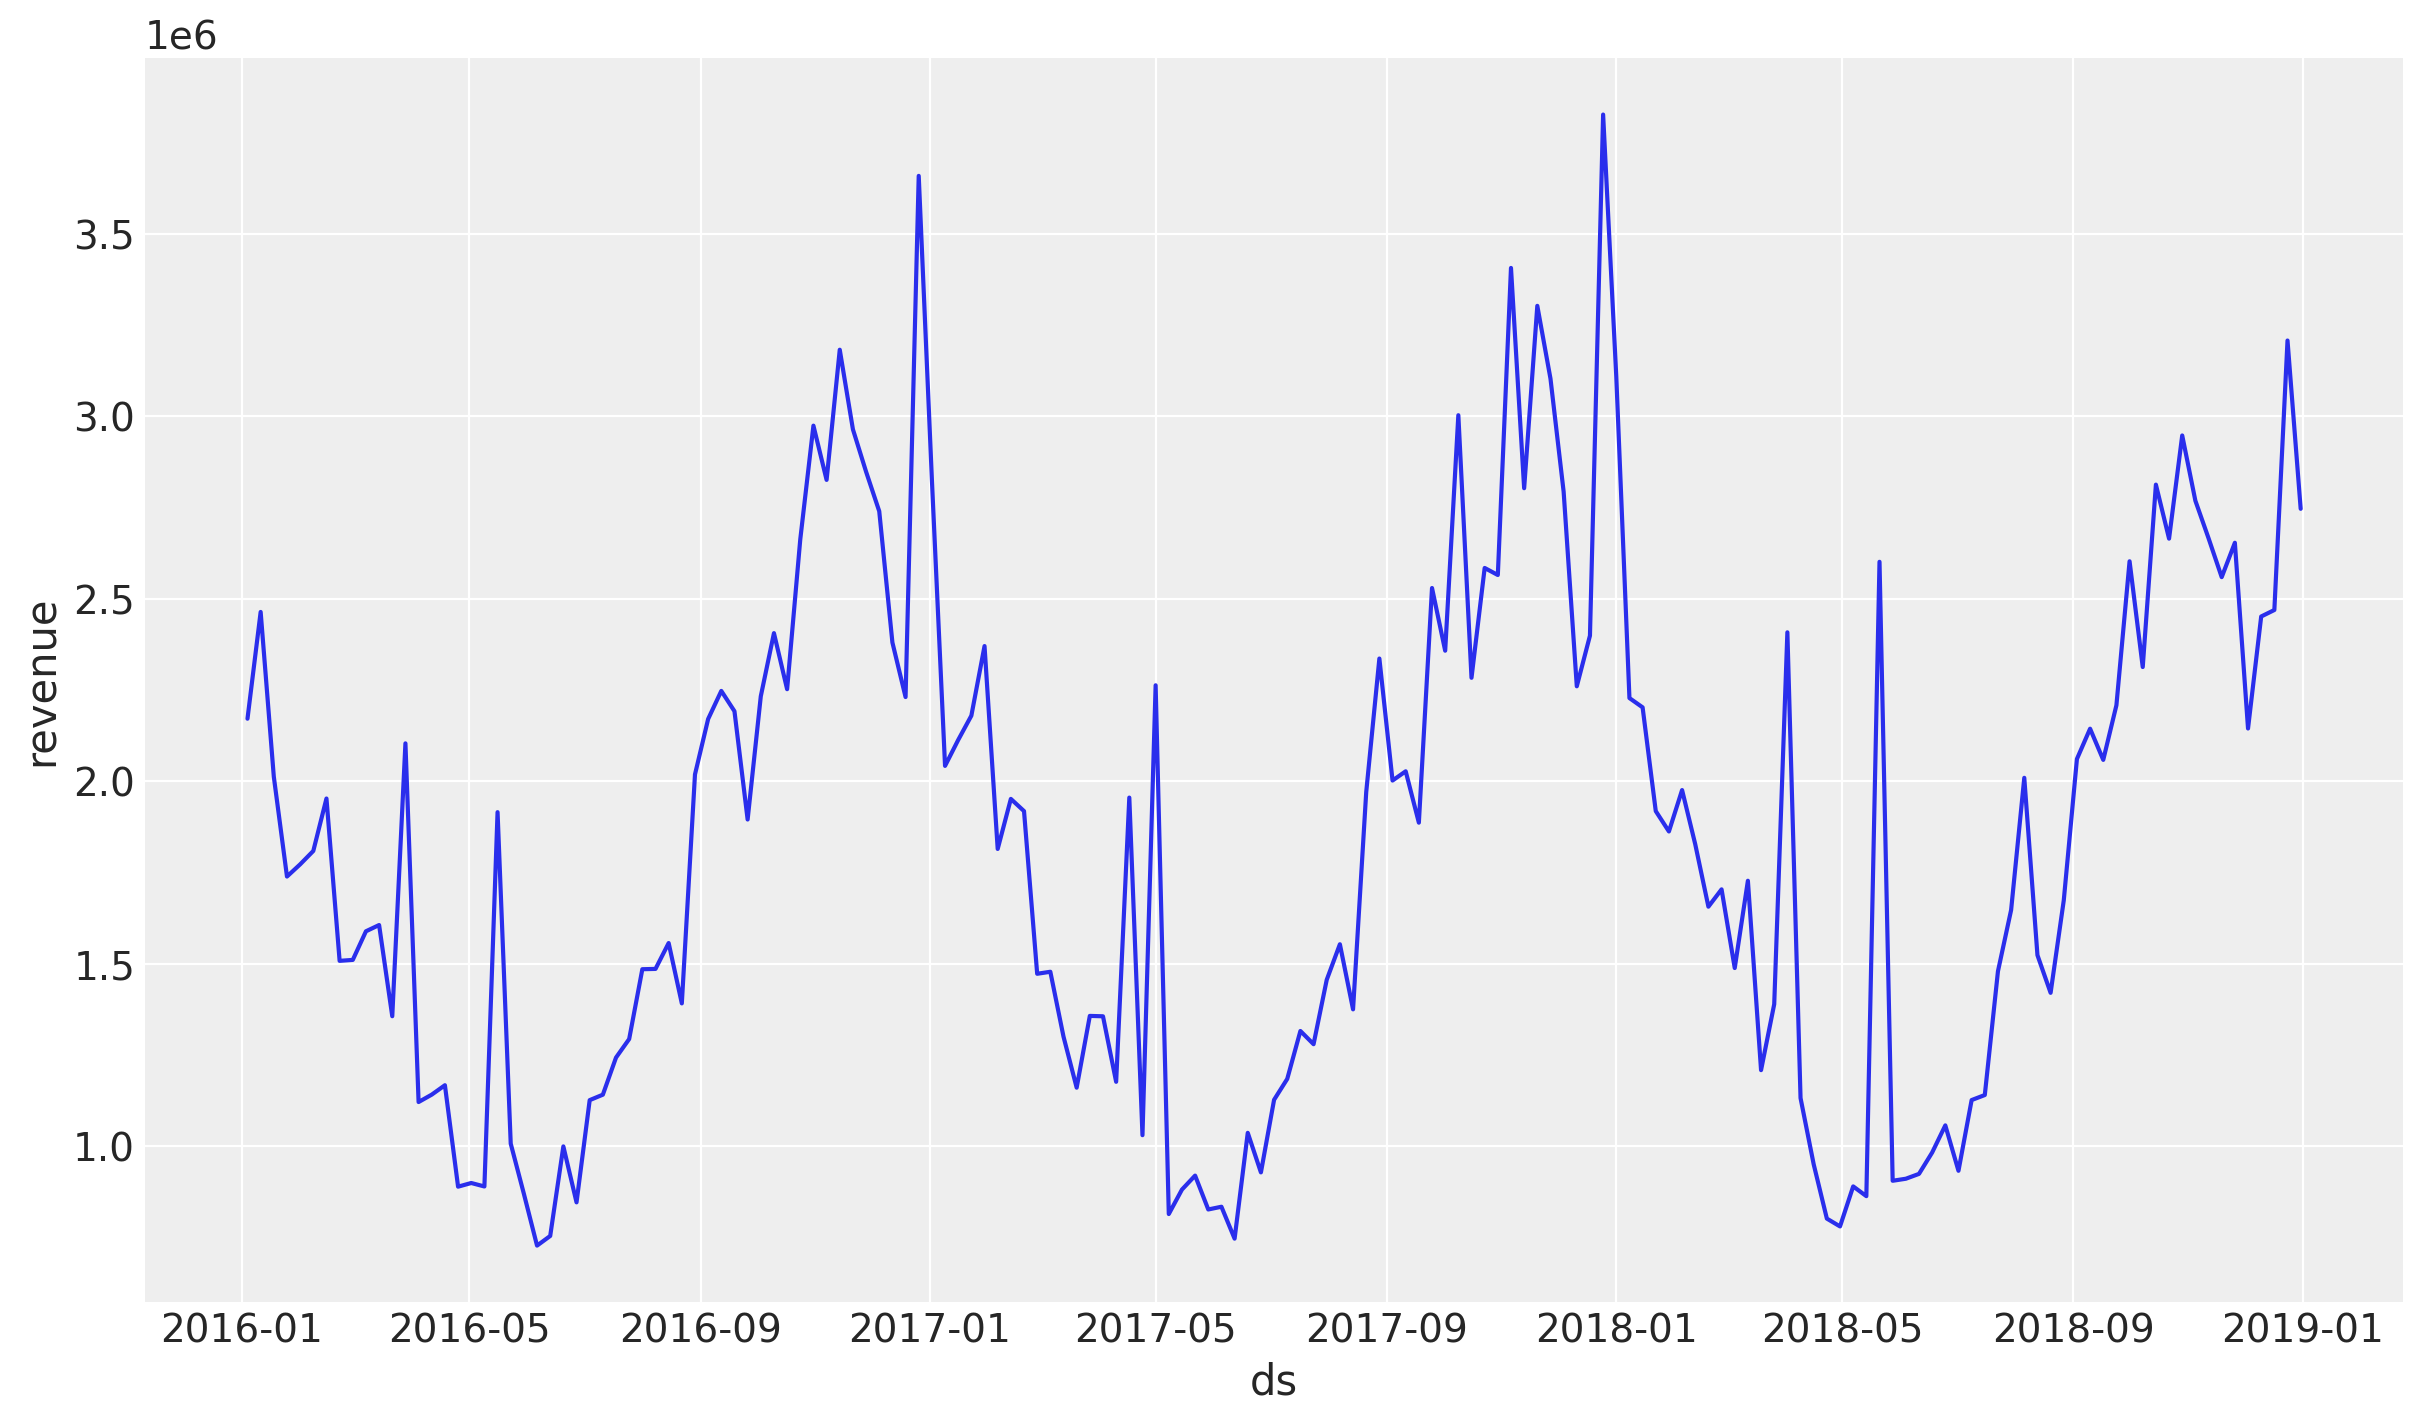

In [7]:
sns.lineplot(df_mmm, x=date_col, y=sales_col)
plt.show()

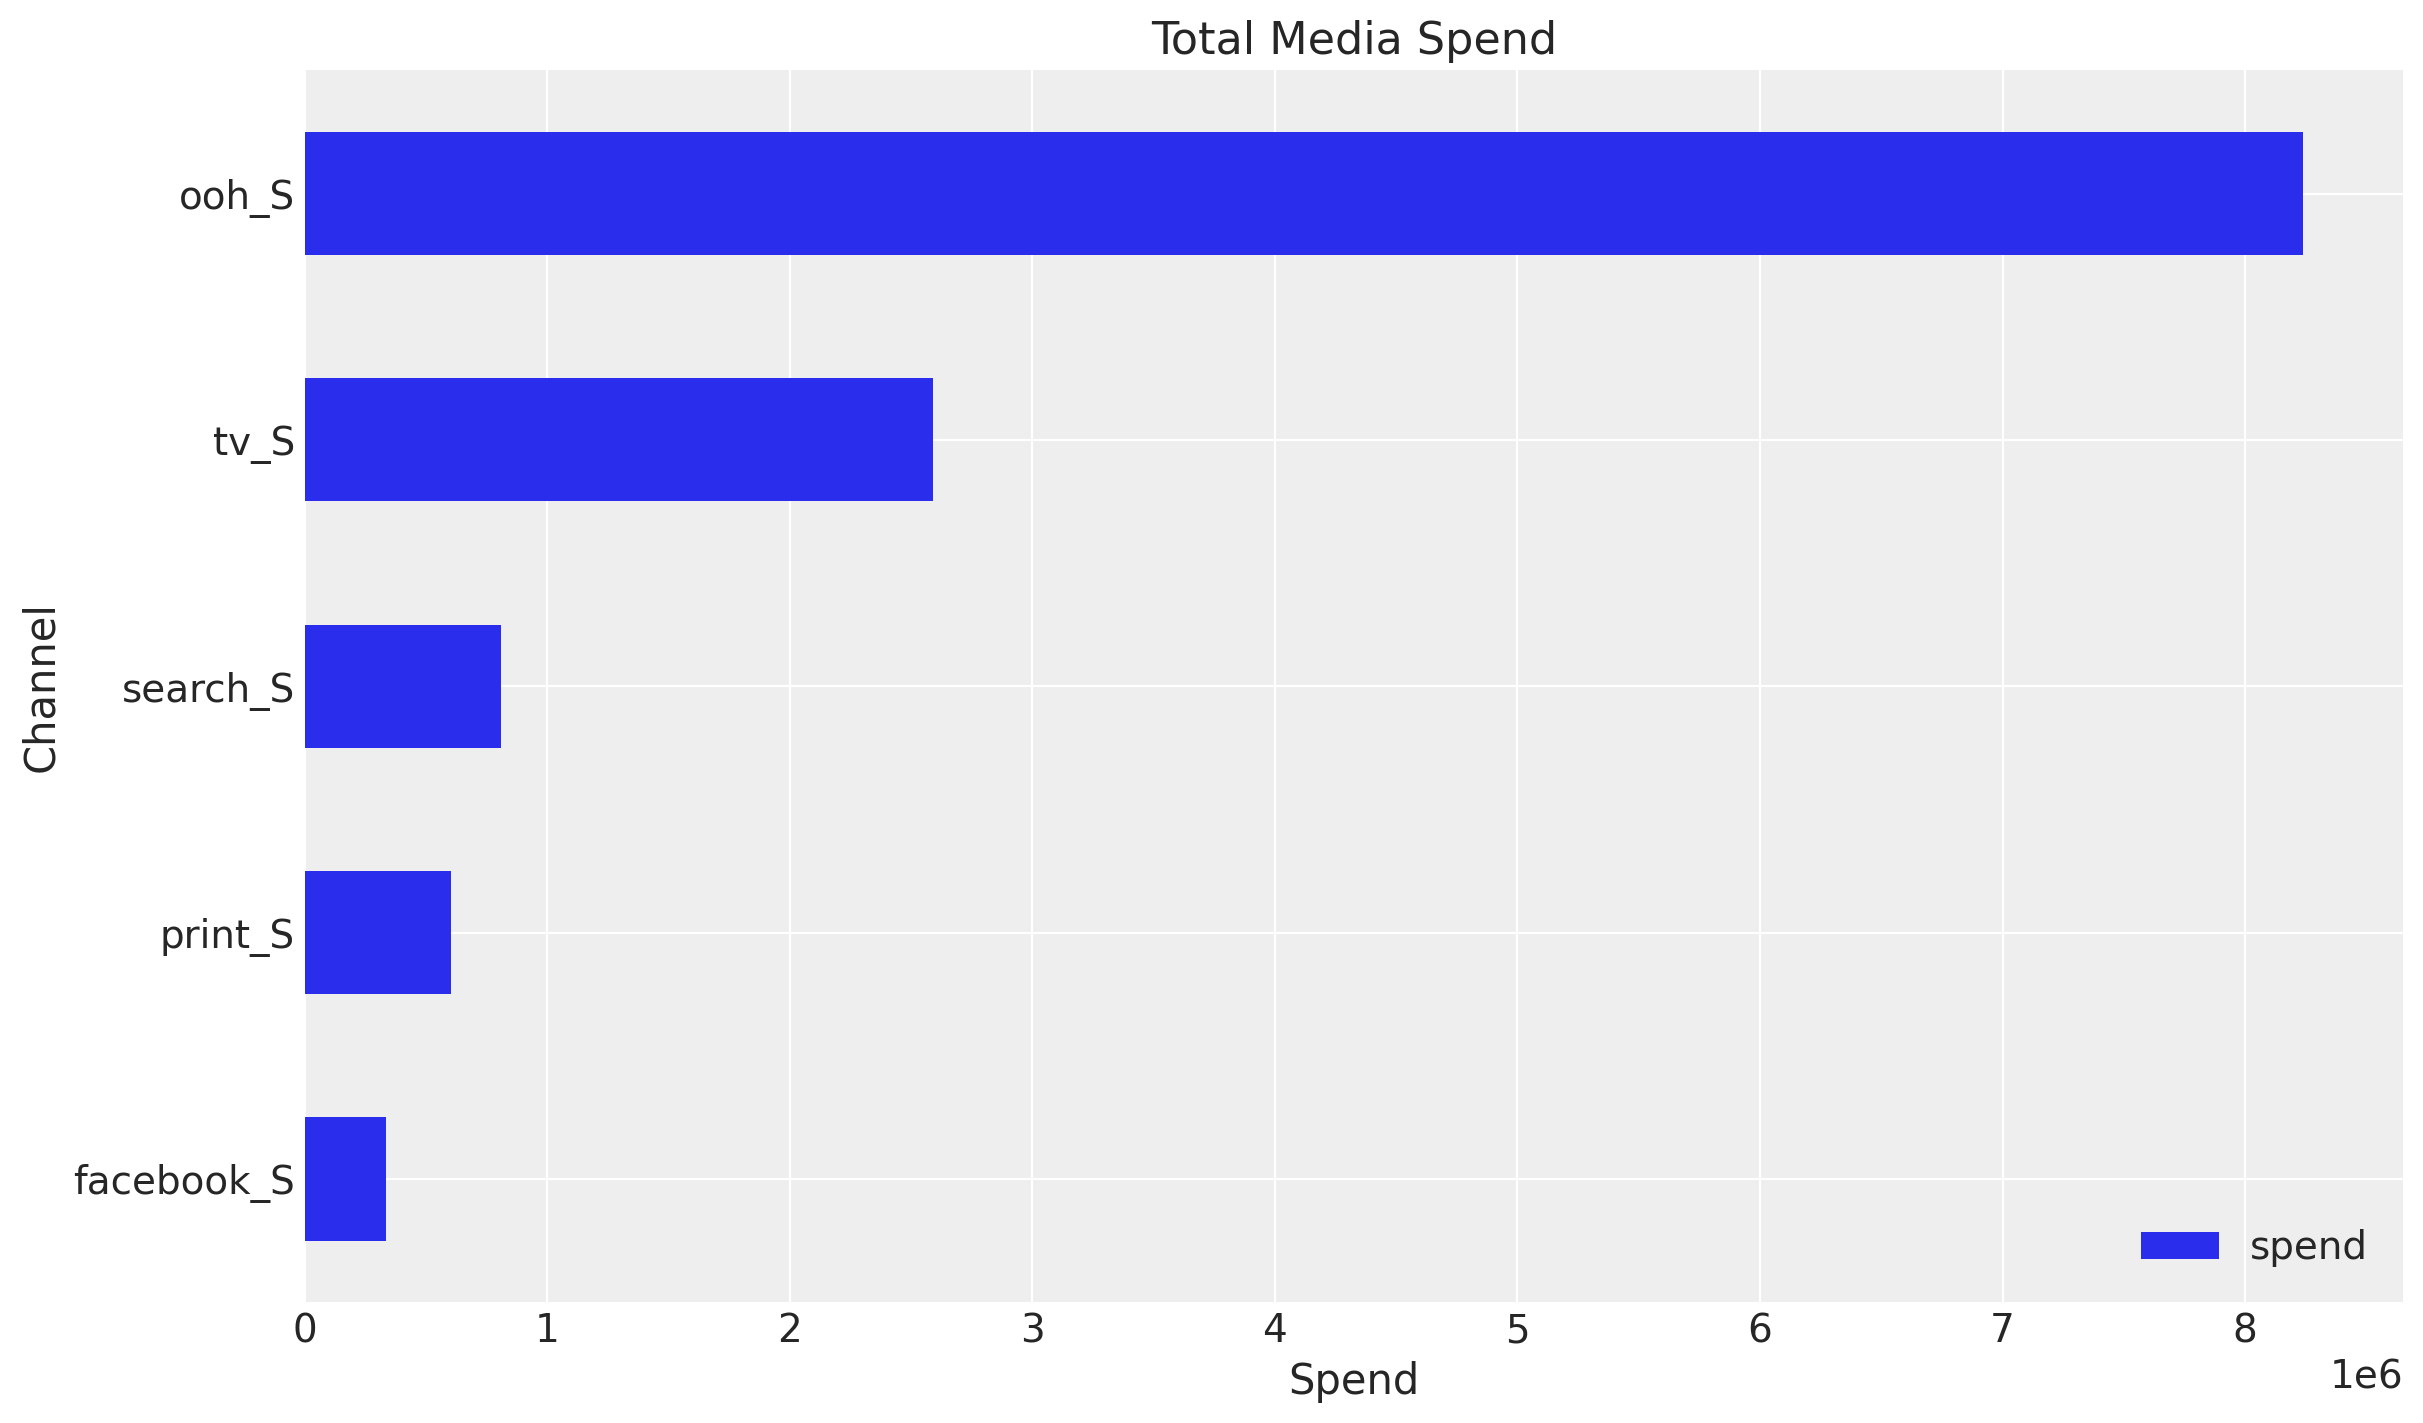

In [8]:
fig, ax = plt.subplots()
df_mmm.melt(
    value_vars=channel_cols, var_name="channel", value_name="spend"
).groupby("channel").agg({"spend": "sum"}).sort_values(by="spend").plot.barh(ax=ax)
ax.set(title="Total Media Spend", xlabel="Spend", ylabel="Channel");

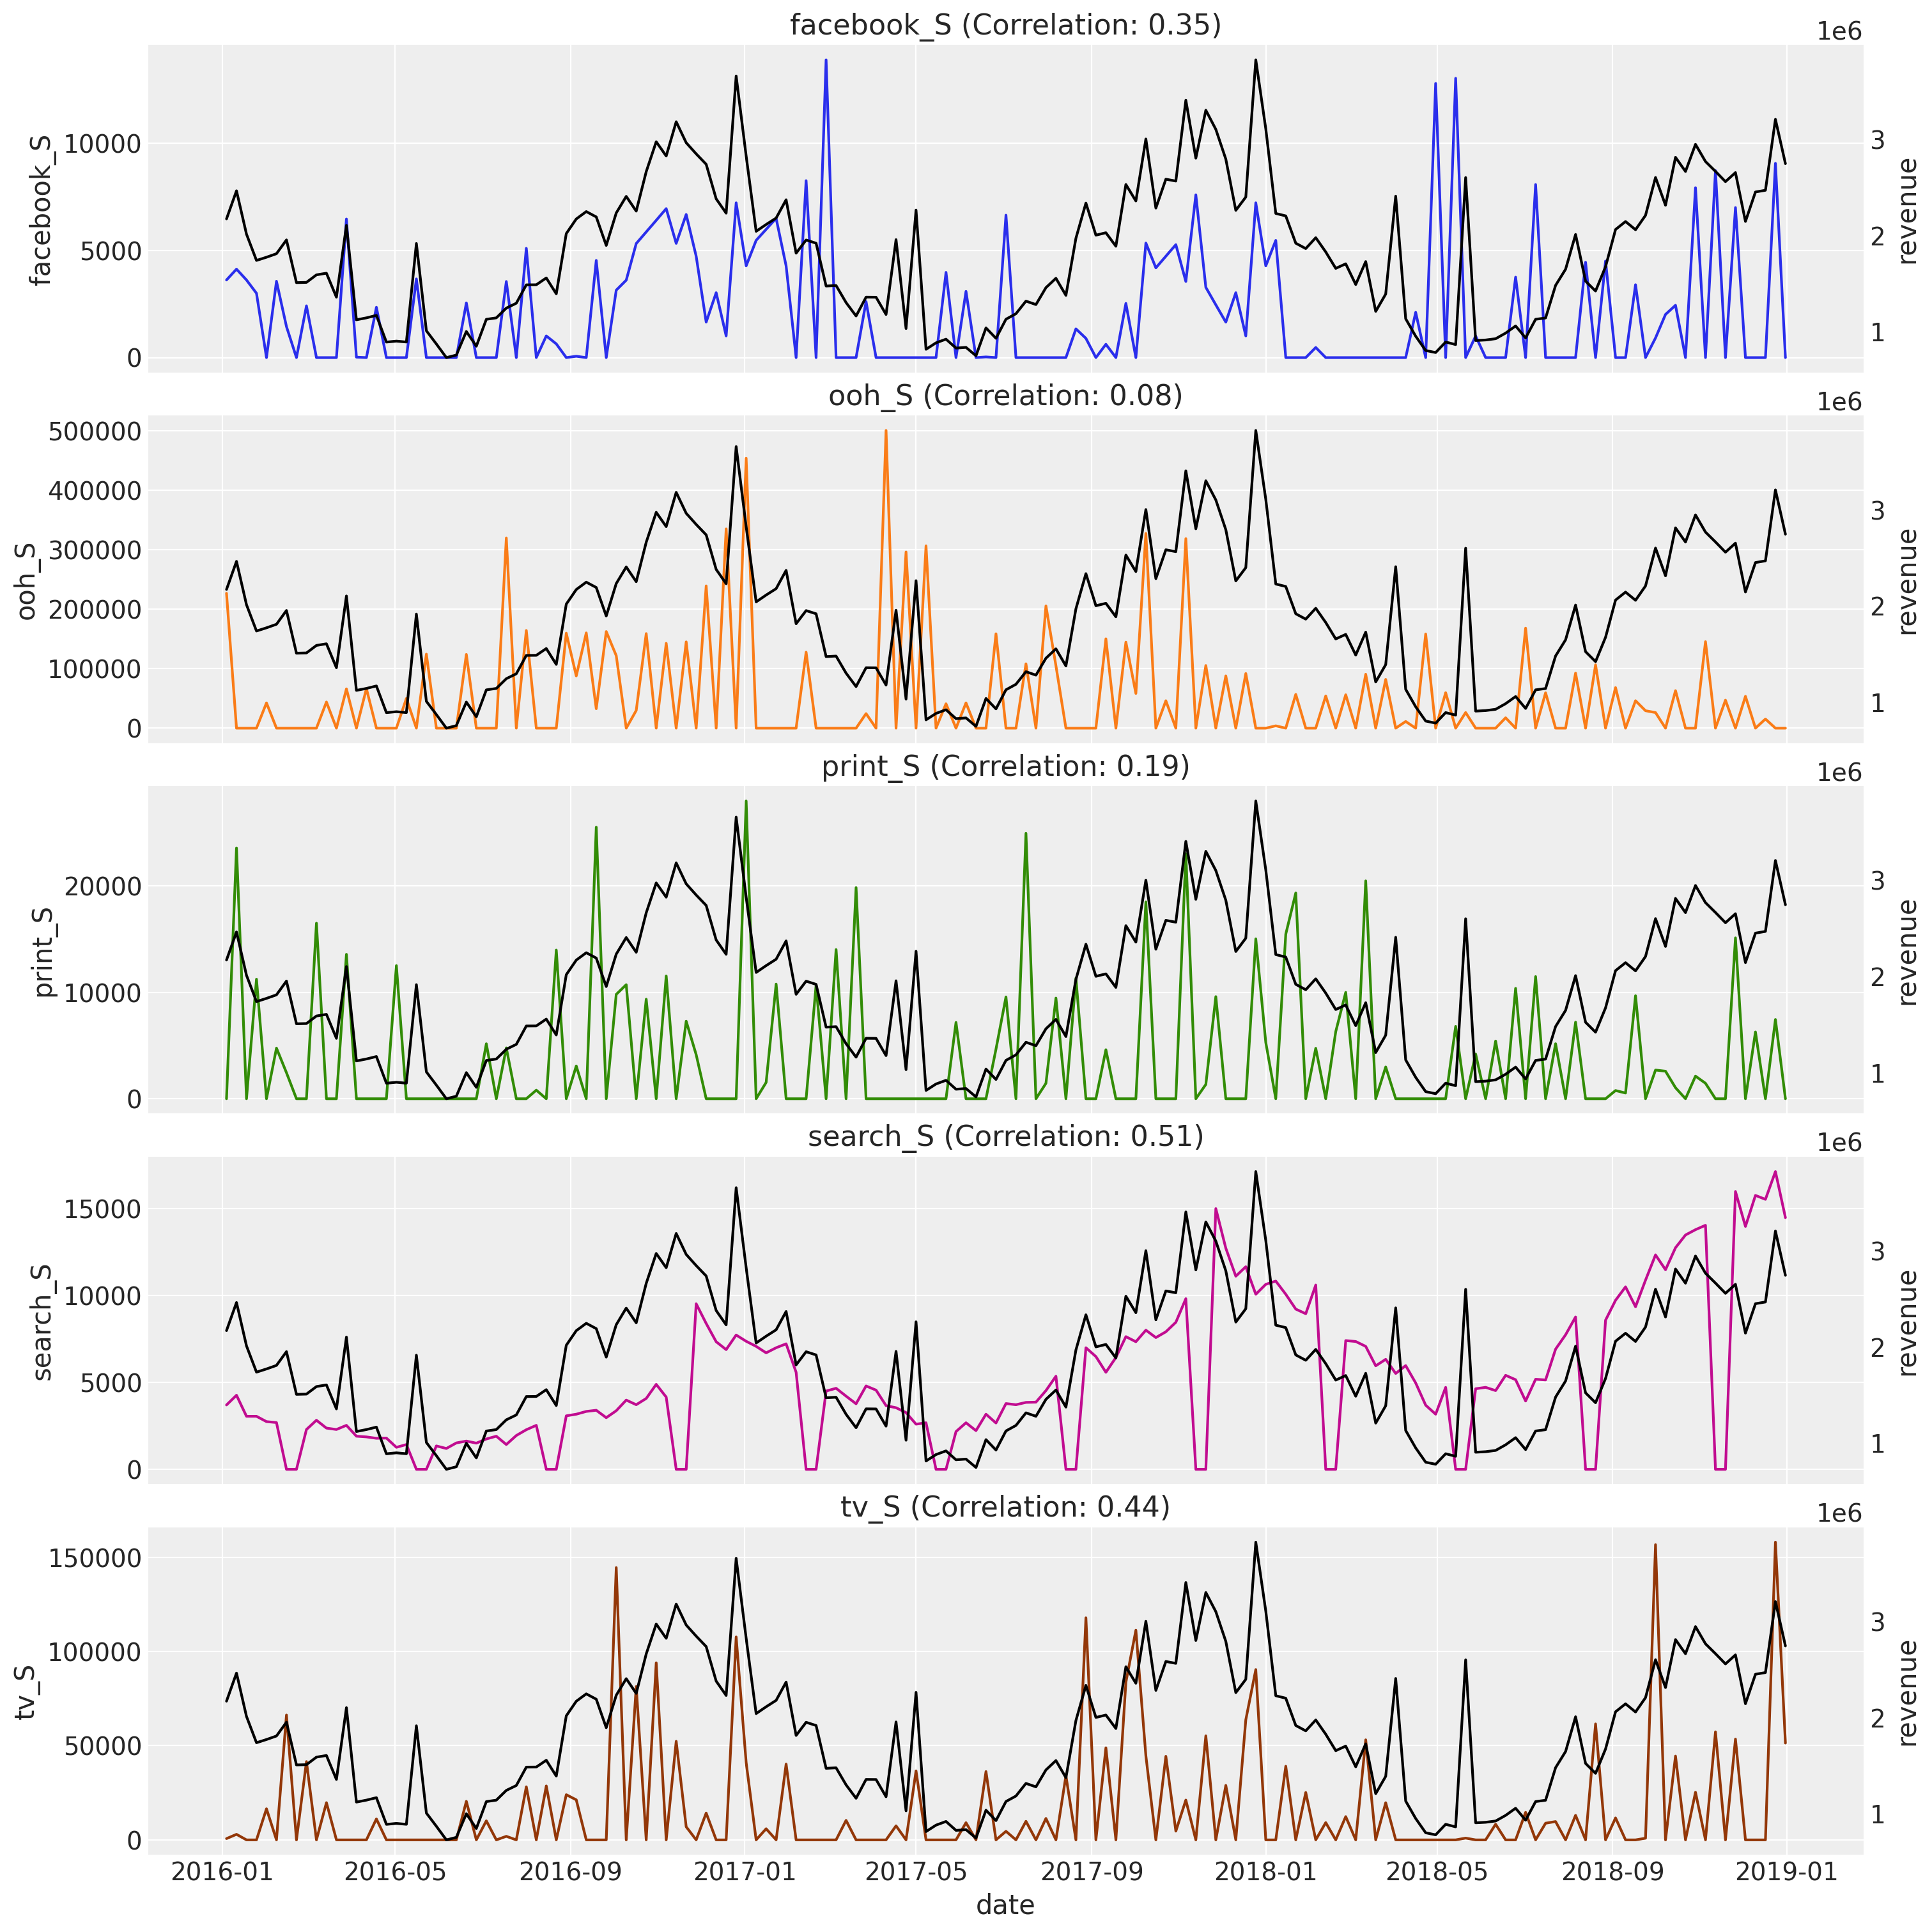

In [9]:
n_channels = len(channel_cols)

fig, axes = plt.subplots(
    nrows=n_channels,
    ncols=1,
    figsize=(15, 3 * n_channels),
    sharex=True,
    sharey=False,
    layout="constrained",
)

for i, channel in enumerate(channel_cols):
    ax = axes[i]
    ax_twin = ax.twinx()
    sns.lineplot(data=df_mmm, x=date_col, y=channel, color=f"C{i}", ax=ax)
    sns.lineplot(data=df_mmm, x=date_col, y=sales_col, color="black", ax=ax_twin)
    correlation = df_mmm[[channel, sales_col]].corr().iloc[0, 1]
    ax_twin.grid(None)
    ax.set(title=f"{channel} (Correlation: {correlation:.2f})")

ax.set_xlabel("date");

# 3. Train Test Split

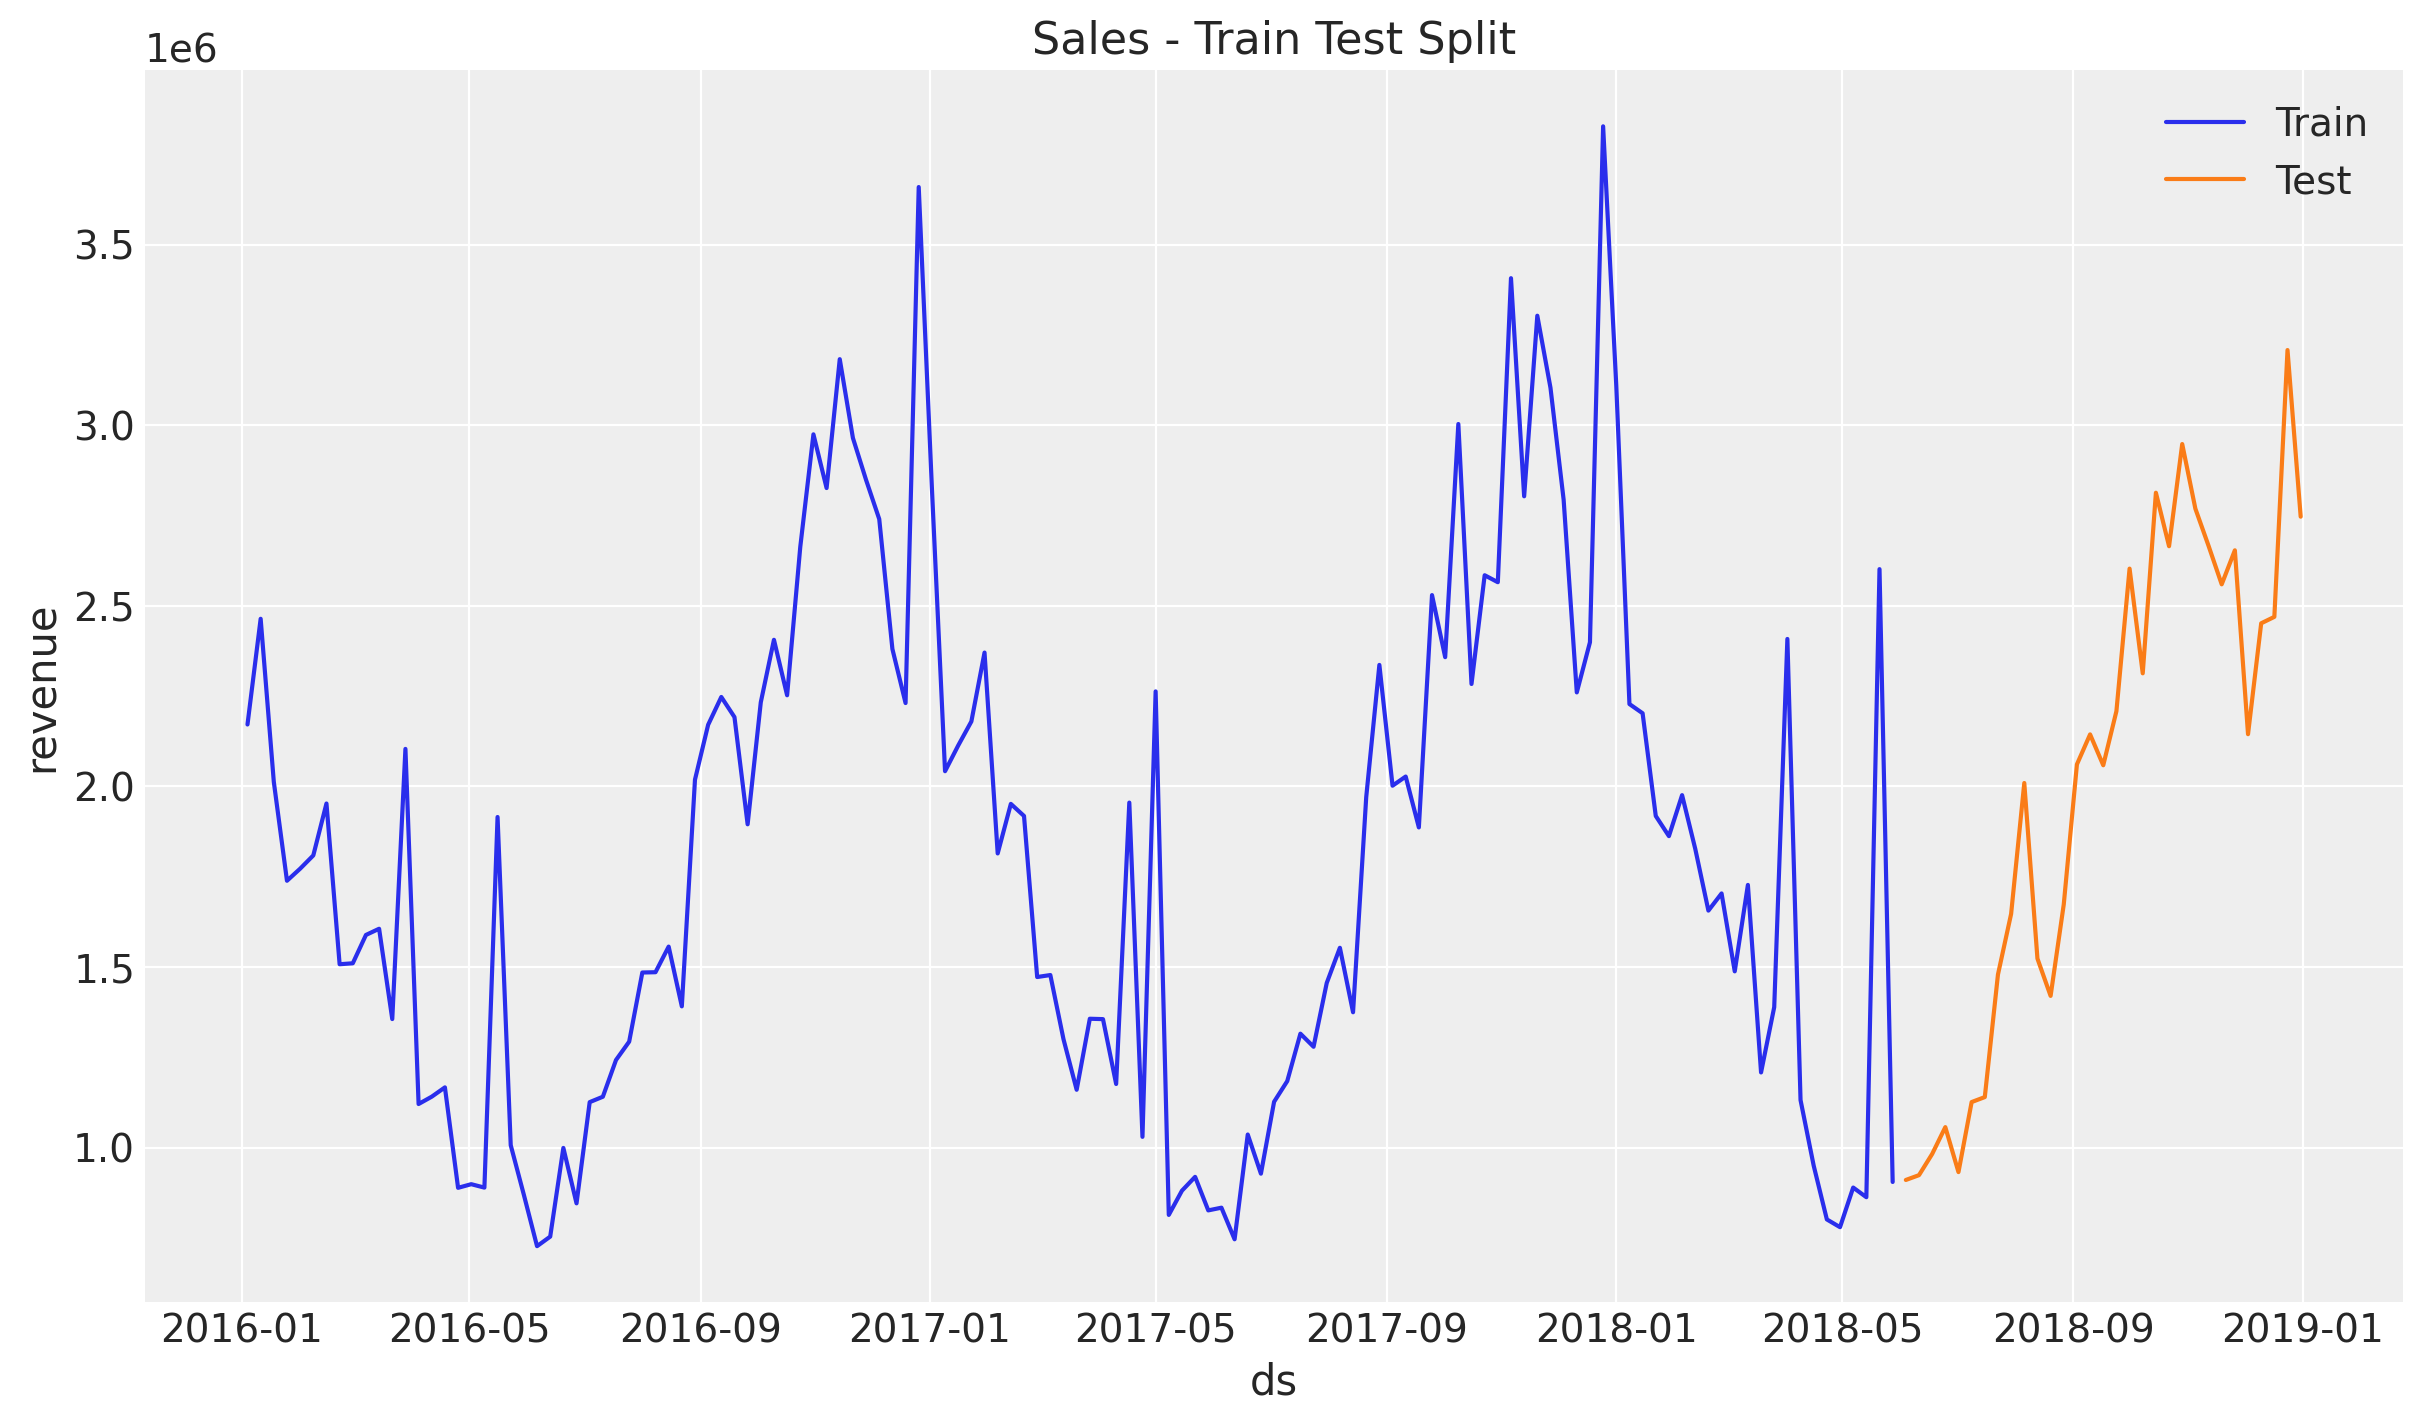

In [10]:
split_date = "2018-06-01"  # 6 months for test

df_train = df_mmm[df_mmm[date_col] < split_date]
df_test = df_mmm[df_mmm[date_col] >= split_date]

sns.lineplot(data=df_train, x=date_col, y=sales_col, color="C0", label="Train")
sns.lineplot(data=df_test, x=date_col, y=sales_col, color="C1", label="Test")
plt.title("Sales - Train Test Split");

In [11]:
X_train = df_train.drop(sales_col, axis=1)
X_test = df_test.drop(sales_col, axis=1)

y_train = df_train[sales_col]
y_test = df_test[sales_col]

# 4. Model Specification

In [12]:
# # Parameters from robyn optimization
# model_spec = {
#     "facebook_S": {
#         "alpha": 2.992003,
#         "gamma": 0.949203,
#         "theta": 0.017215,
#     },
#     "newsletter": {
#         "alpha": 1.102317,
#         "gamma": 0.998069,
#         "theta": 0.390837,
#     },
#     "ooh_S": {
#         "alpha": 0.500313,
#         "gamma": 0.348616,
#         "theta": 0.394762,
#     },
#     "print_S": {
#         "alpha": 2.950387,
#         "gamma": 0.314979,
#         "theta": 0.366256,
#     },
#     "search_S": {
#         "alpha": 0.718514,
#         "gamma": 0.458433,
#         "theta": 0.11901,
#     },
#     "tv_S": {
#         "alpha": 2.916362,
#         "gamma": 0.612891,
#         "theta": 0.526186,
#     },
# }

In [13]:
# spends priors
spend_shares = (
    X_train.melt(value_vars=channel_cols, var_name="channel", value_name="spend")
    .groupby("channel", as_index=False)
    .agg({"spend": "sum"})
    .sort_values(by="channel")
    .assign(spend_share=lambda x: x["spend"] / x["spend"].sum())
)

prior_sigma = spend_shares["spend_share"].to_numpy()

display(spend_shares, prior_sigma)

,channel,spend,spend_share
0,facebook_S,2.717720e+05,0.025800
1,ooh_S,7.301249e+06,0.693138
2,print_S,5.121968e+05,0.048625
3,search_S,5.324533e+05,0.050548
4,tv_S,1.915951e+06,0.181889


array([0.02580043, 0.69313752, 0.04862495, 0.05054798, 0.18188912])

In [14]:
model_config = {
    "intercept": Prior("Normal", mu=0.2, sigma=0.05),
    "saturation_beta": Prior("HalfNormal", sigma=prior_sigma, dims="channel"),
    "saturation_lam": Prior("Gamma", alpha=3, beta=1, dims="channel"),
    "gamma_control": Prior("Normal", mu=0, sigma=1),
    "gamma_fourier": Prior("Laplace", mu=0, b=1),
    "likelihood": Prior("TruncatedNormal", lower=0, sigma=Prior("HalfNormal", sigma=1)),
}

In [15]:
sampler_config = {"progressbar": True}

mmm = MMM(
    model_config=model_config,
    sampler_config=sampler_config,
    date_column=date_col,
    adstock=GeometricAdstock(l_max=6),
    saturation=LogisticSaturation(),
    channel_columns=channel_cols,
    control_columns=control_cols,
    yearly_seasonality=2,
)

# 5. Prior Predictive Checks

Sampling: [adstock_alpha, gamma_control, gamma_fourier, intercept, saturation_beta, saturation_lam, y, y_sigma]


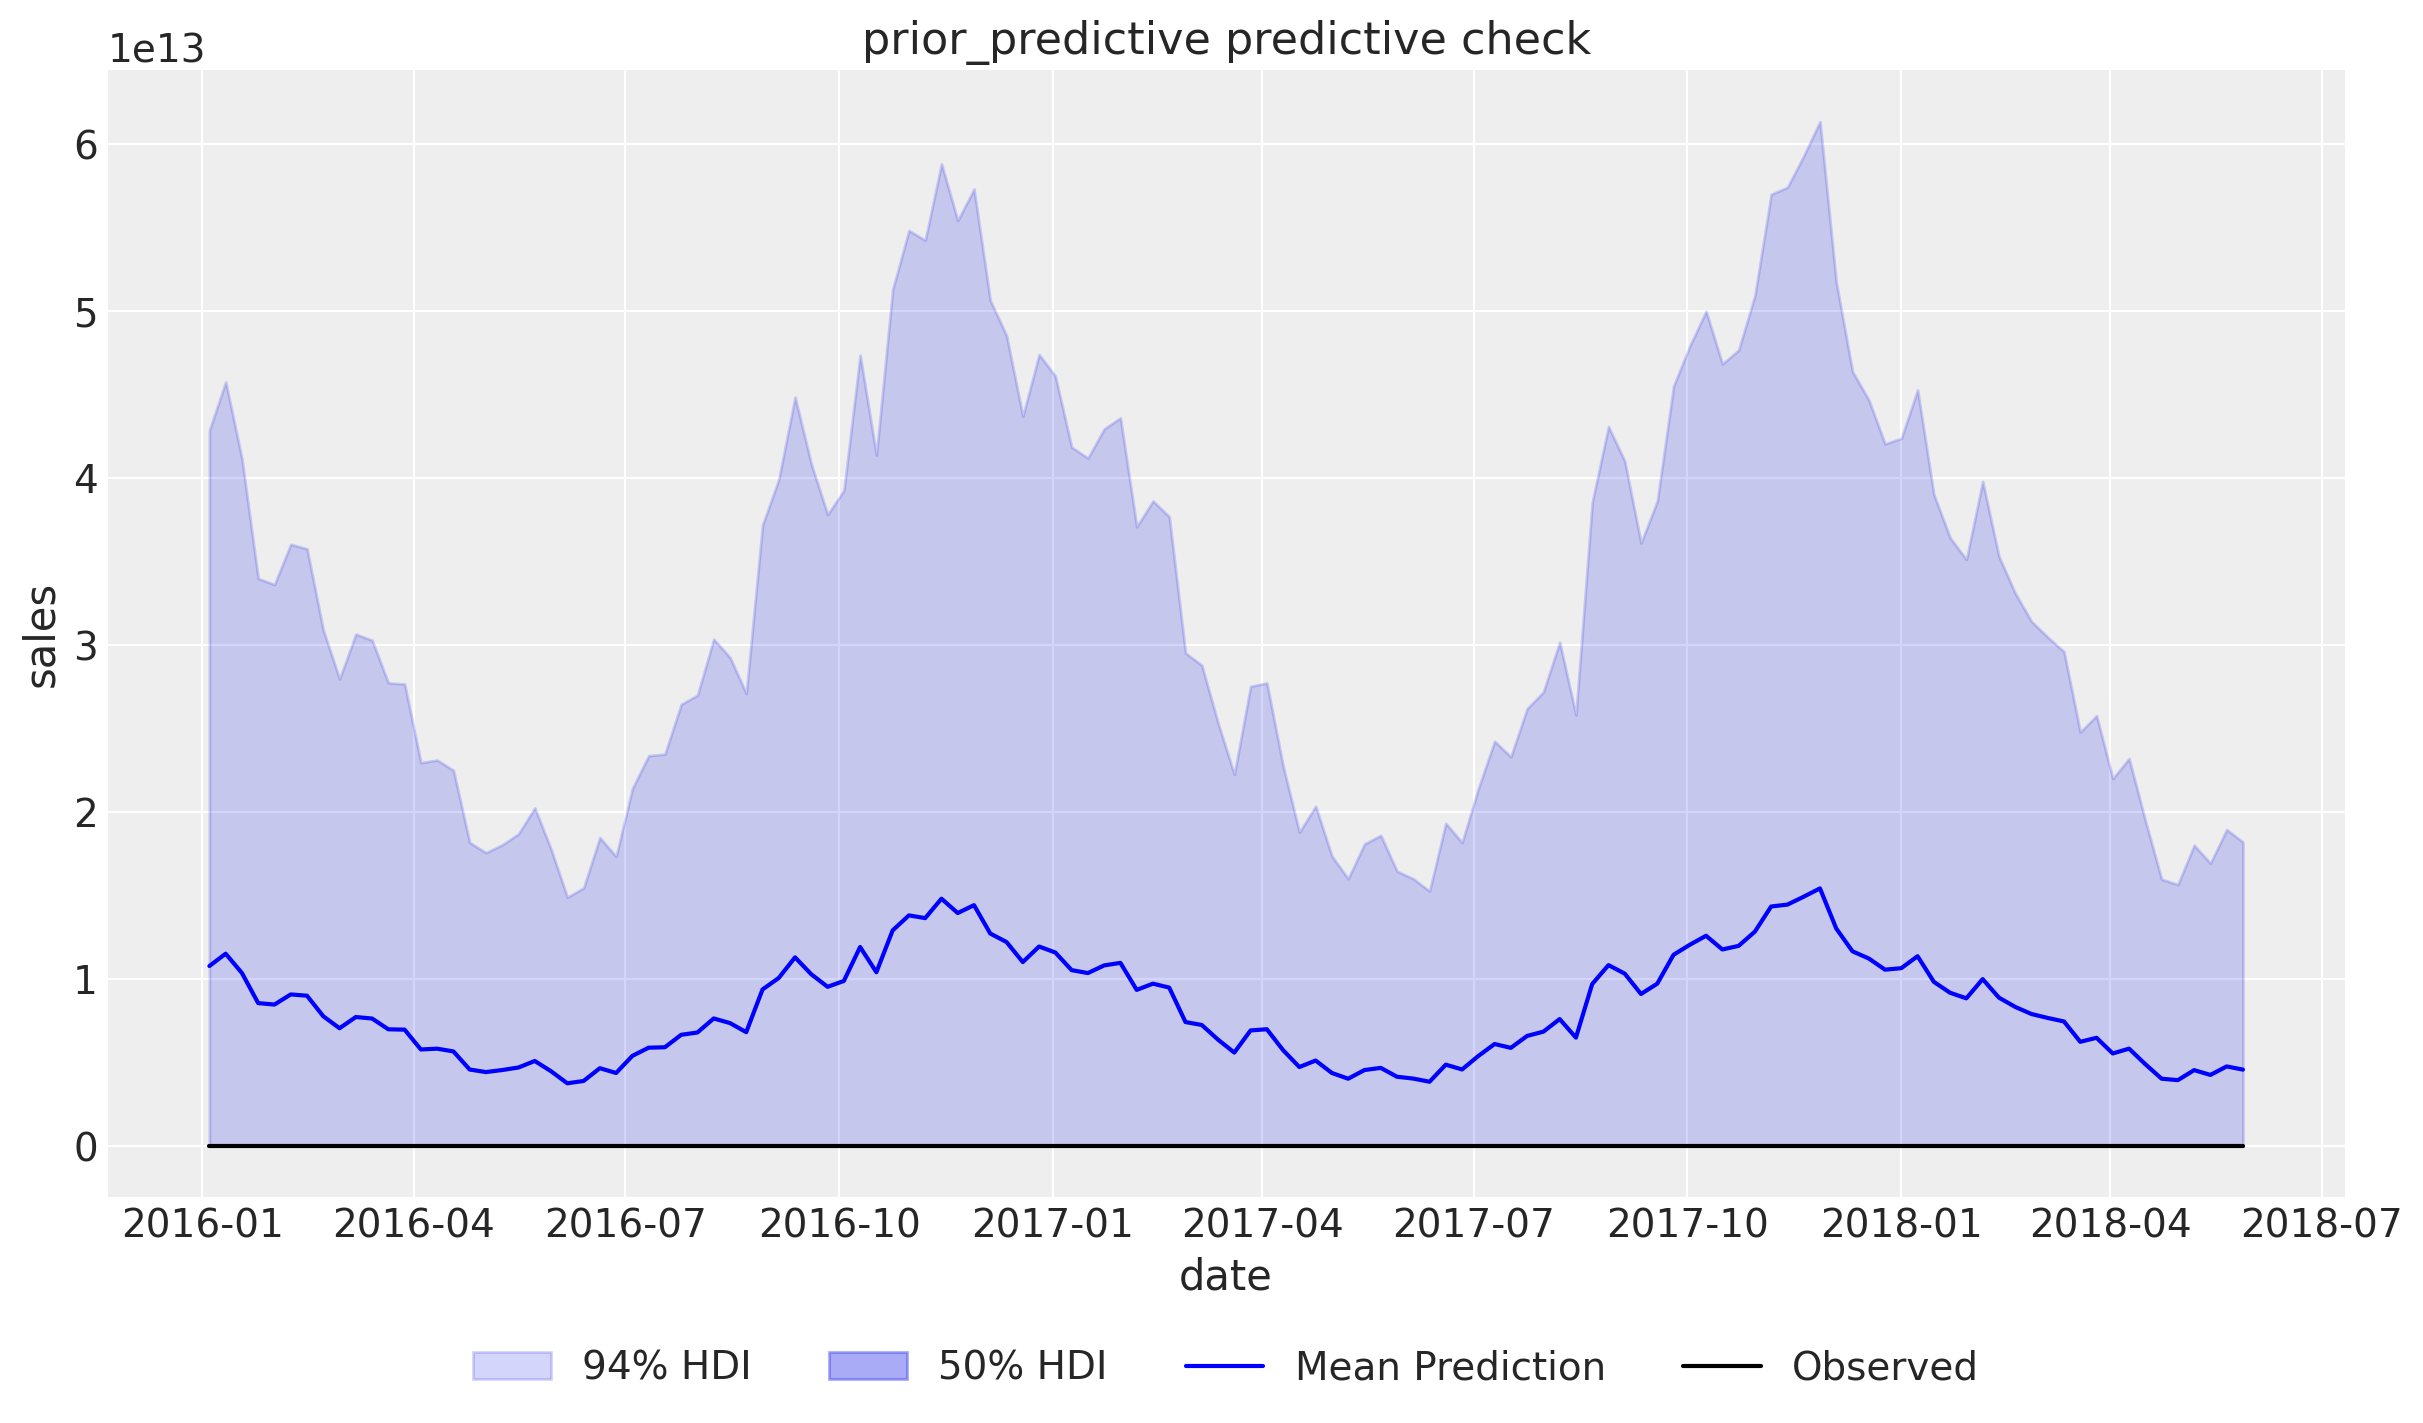

In [16]:
# Generate prior predictive samples
mmm.sample_prior_predictive(X_train, y_train, samples=4_000)

fig, ax = plt.subplots()
fig = mmm.plot_prior_predictive(original_scale=True, ax=ax)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.2), ncol=4)
ax.set(xlabel="date", ylabel="sales");

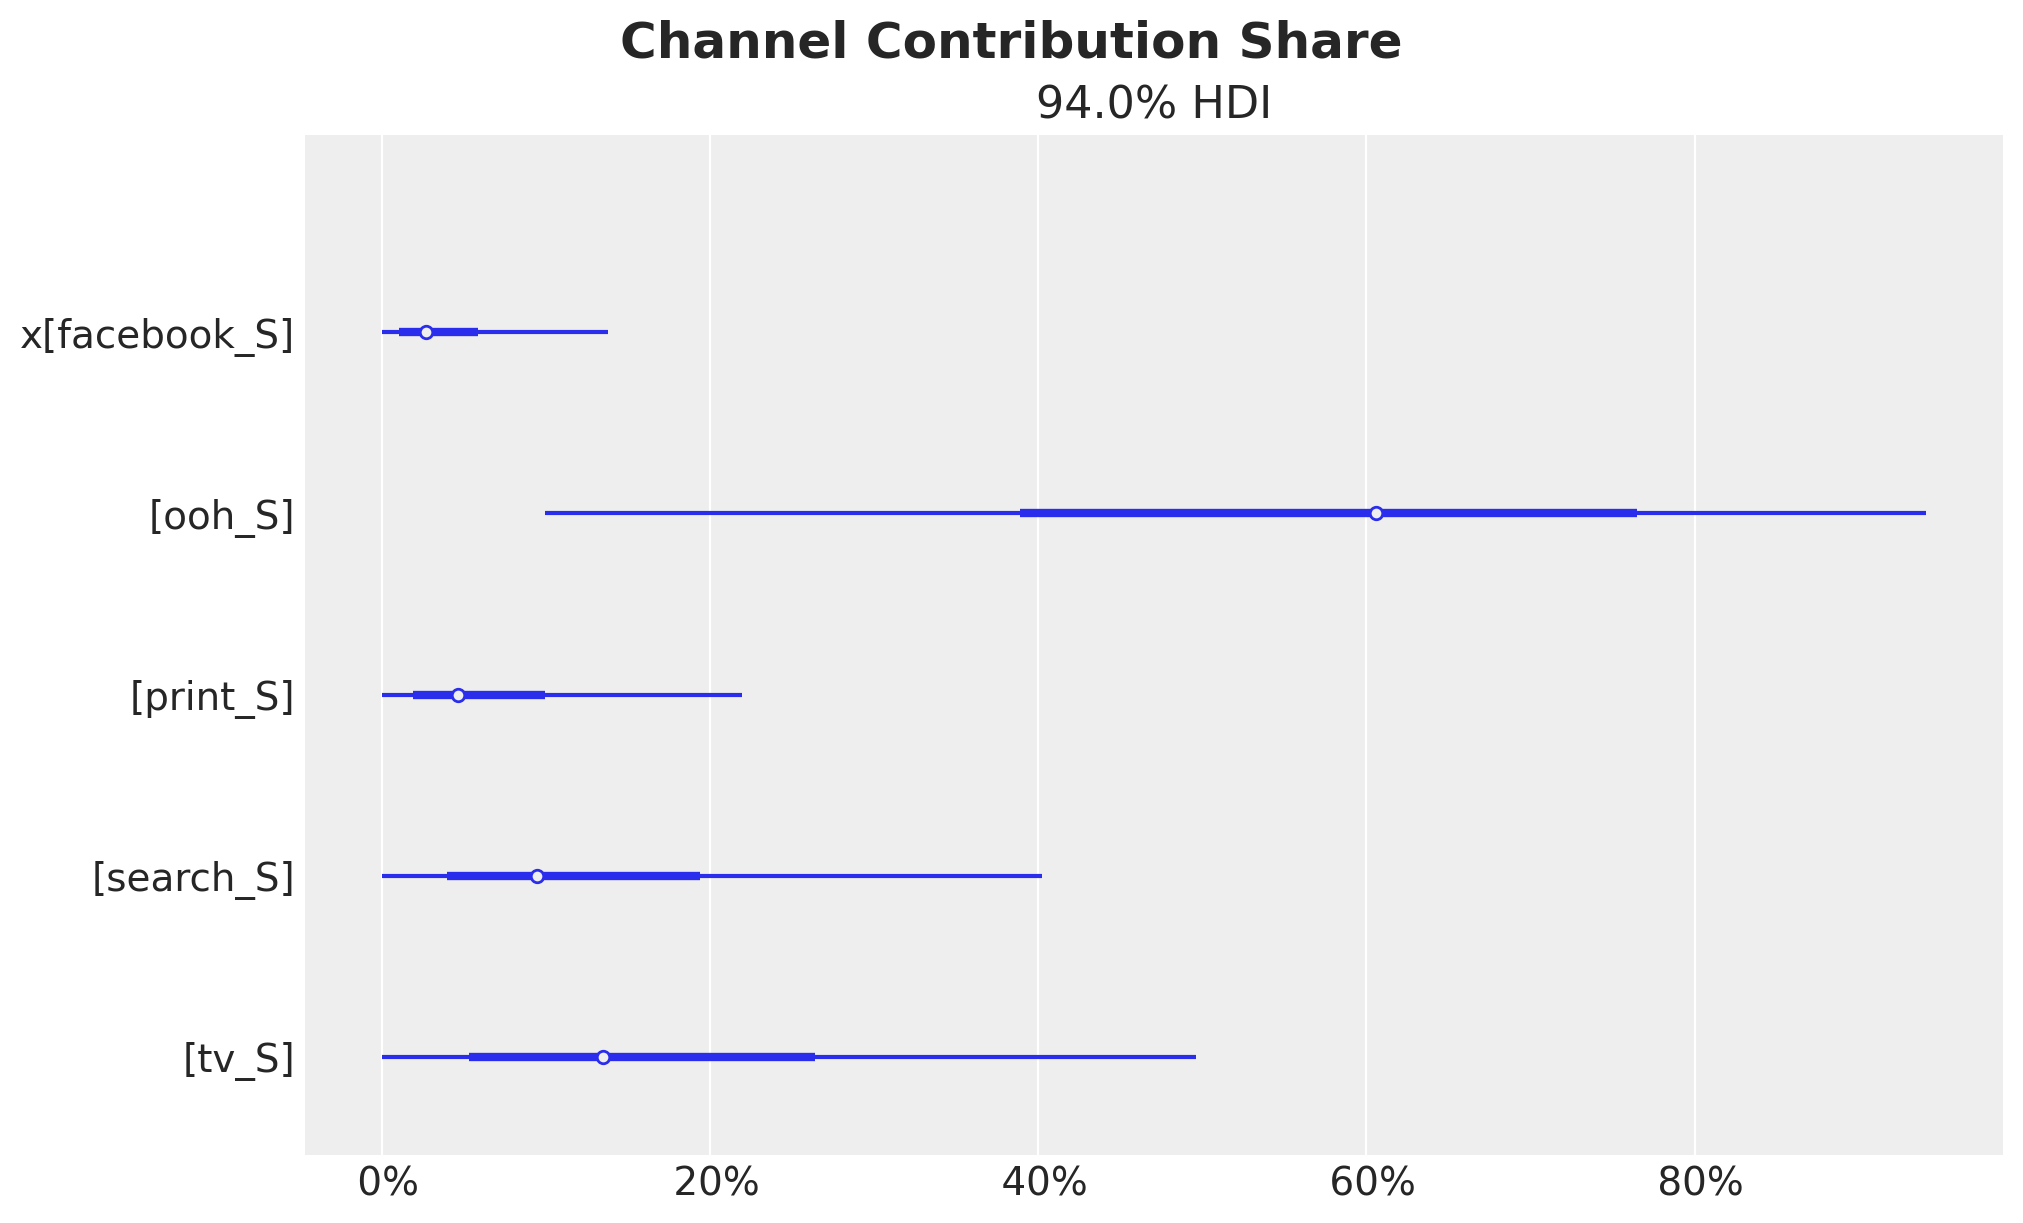

In [17]:
fig = mmm.plot_channel_contribution_share_hdi(prior=True, figsize=(10, 6))
fig.suptitle("Channel Contribution Share", fontsize=18, fontweight="bold");

# 6. Model Fitting

In [18]:
mmm.fit(
    X=X_train,
    y=y_train,
    target_accept=0.85,
    chains=4,
    draws=1_000,
    nuts_sampler="numpyro",
    random_seed=1,
)

/anaconda/envs/mkt-mix-modeling/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Compiling.. :   0%|                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

/anaconda/envs/mkt-mix-modeling/lib/python3.13/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data
	> fit_data

# 7. Model Diagnostics

In [21]:
# Number of diverging samples
divergent = mmm.idata["sample_stats"]["diverging"].sum().item()
print(f"{divergent} divergent transitions")

4000 divergent transitions


In [22]:
az.summary(
    data=mmm.idata,
    var_names=[
        "intercept",
        "y_sigma",
        "saturation_beta",
        "saturation_lam",
        "adstock_alpha",
        "gamma_control",
        "gamma_fourier",
    ],
)["r_hat"].describe()

count          25.00
mean     31633592.87
std             0.00
min      31633592.87
25%      31633592.87
50%      31633592.87
75%      31633592.87
max      31633592.87
Name: r_hat, dtype: float64

/anaconda/envs/mkt-mix-modeling/lib/python3.13/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/anaconda/envs/mkt-mix-modeling/lib/python3.13/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/anaconda/envs/mkt-mix-modeling/lib/python3.13/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/anaconda/envs/mkt-mix-modeling/lib/python3.13/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/ana

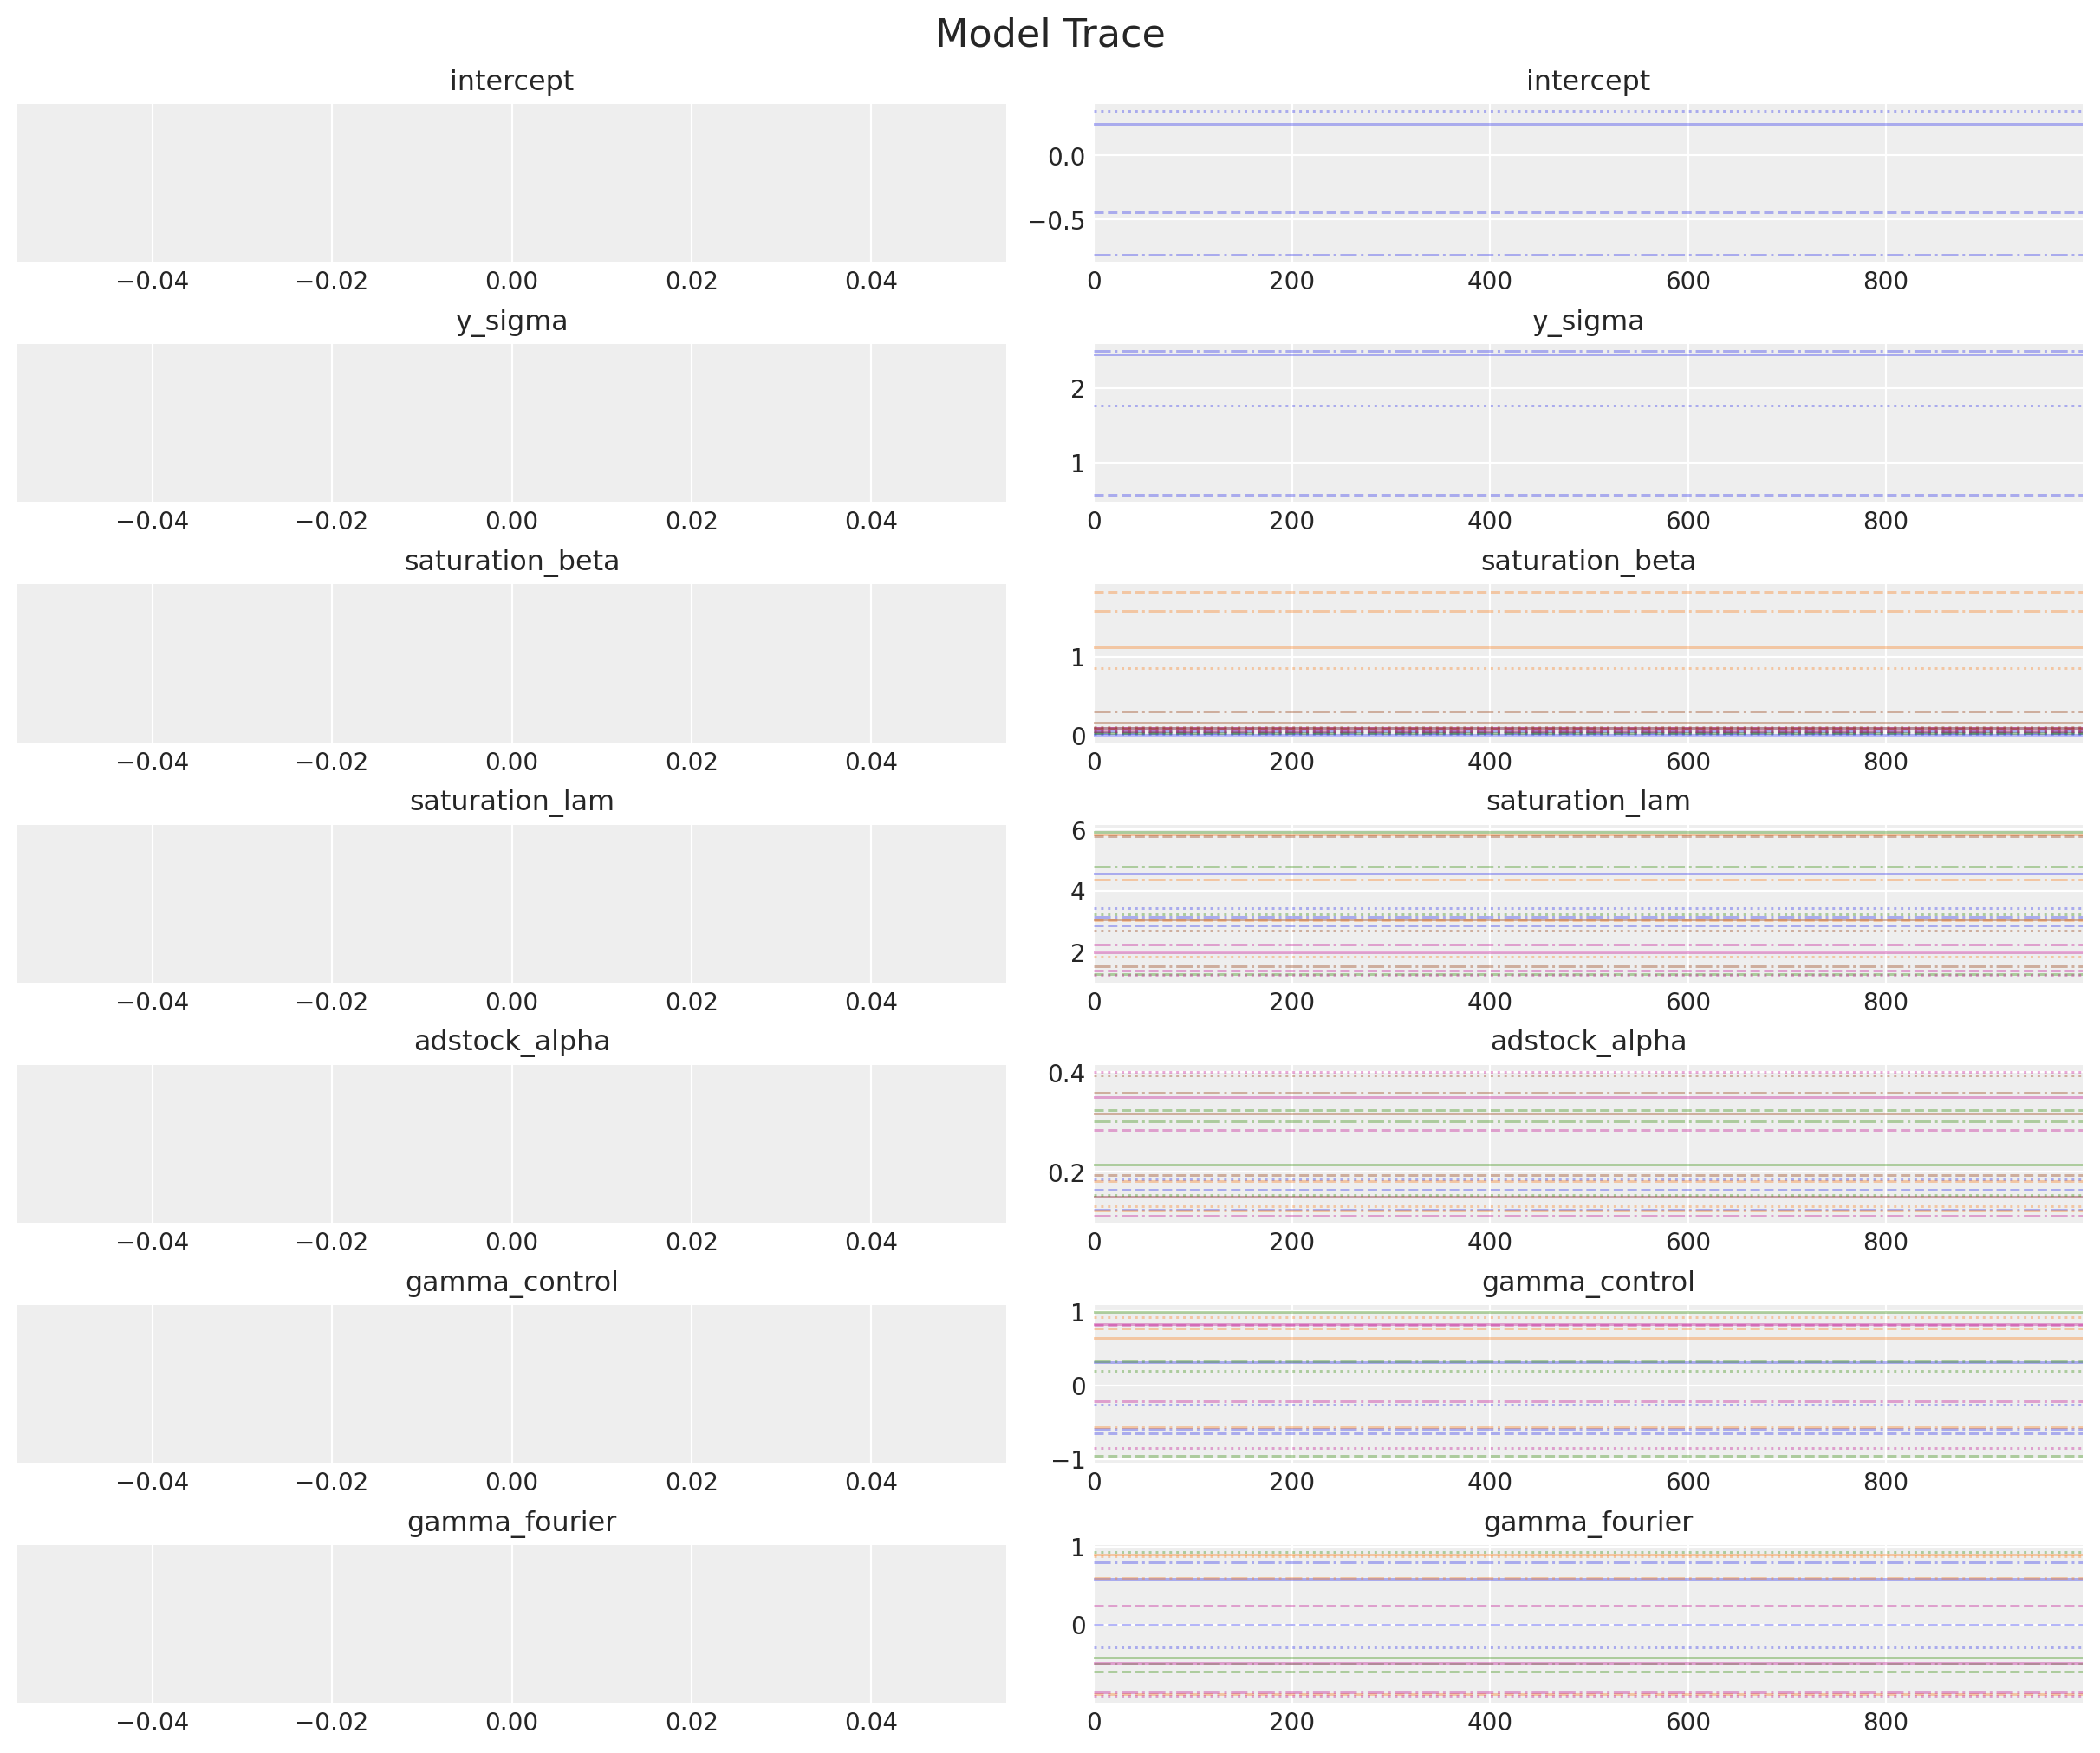

In [23]:
_ = az.plot_trace(
    data=mmm.fit_result,
    var_names=[
        "intercept",
        "y_sigma",
        "saturation_beta",
        "saturation_lam",
        "adstock_alpha",
        "gamma_control",
        "gamma_fourier",
    ],
    compact=True,
    backend_kwargs={"figsize": (12, 10), "layout": "constrained"},
)
plt.gcf().suptitle("Model Trace", fontsize=16);

# 8. Posterior Predictive Checks

Sampling: [y]


/anaconda/envs/mkt-mix-modeling/lib/python3.13/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

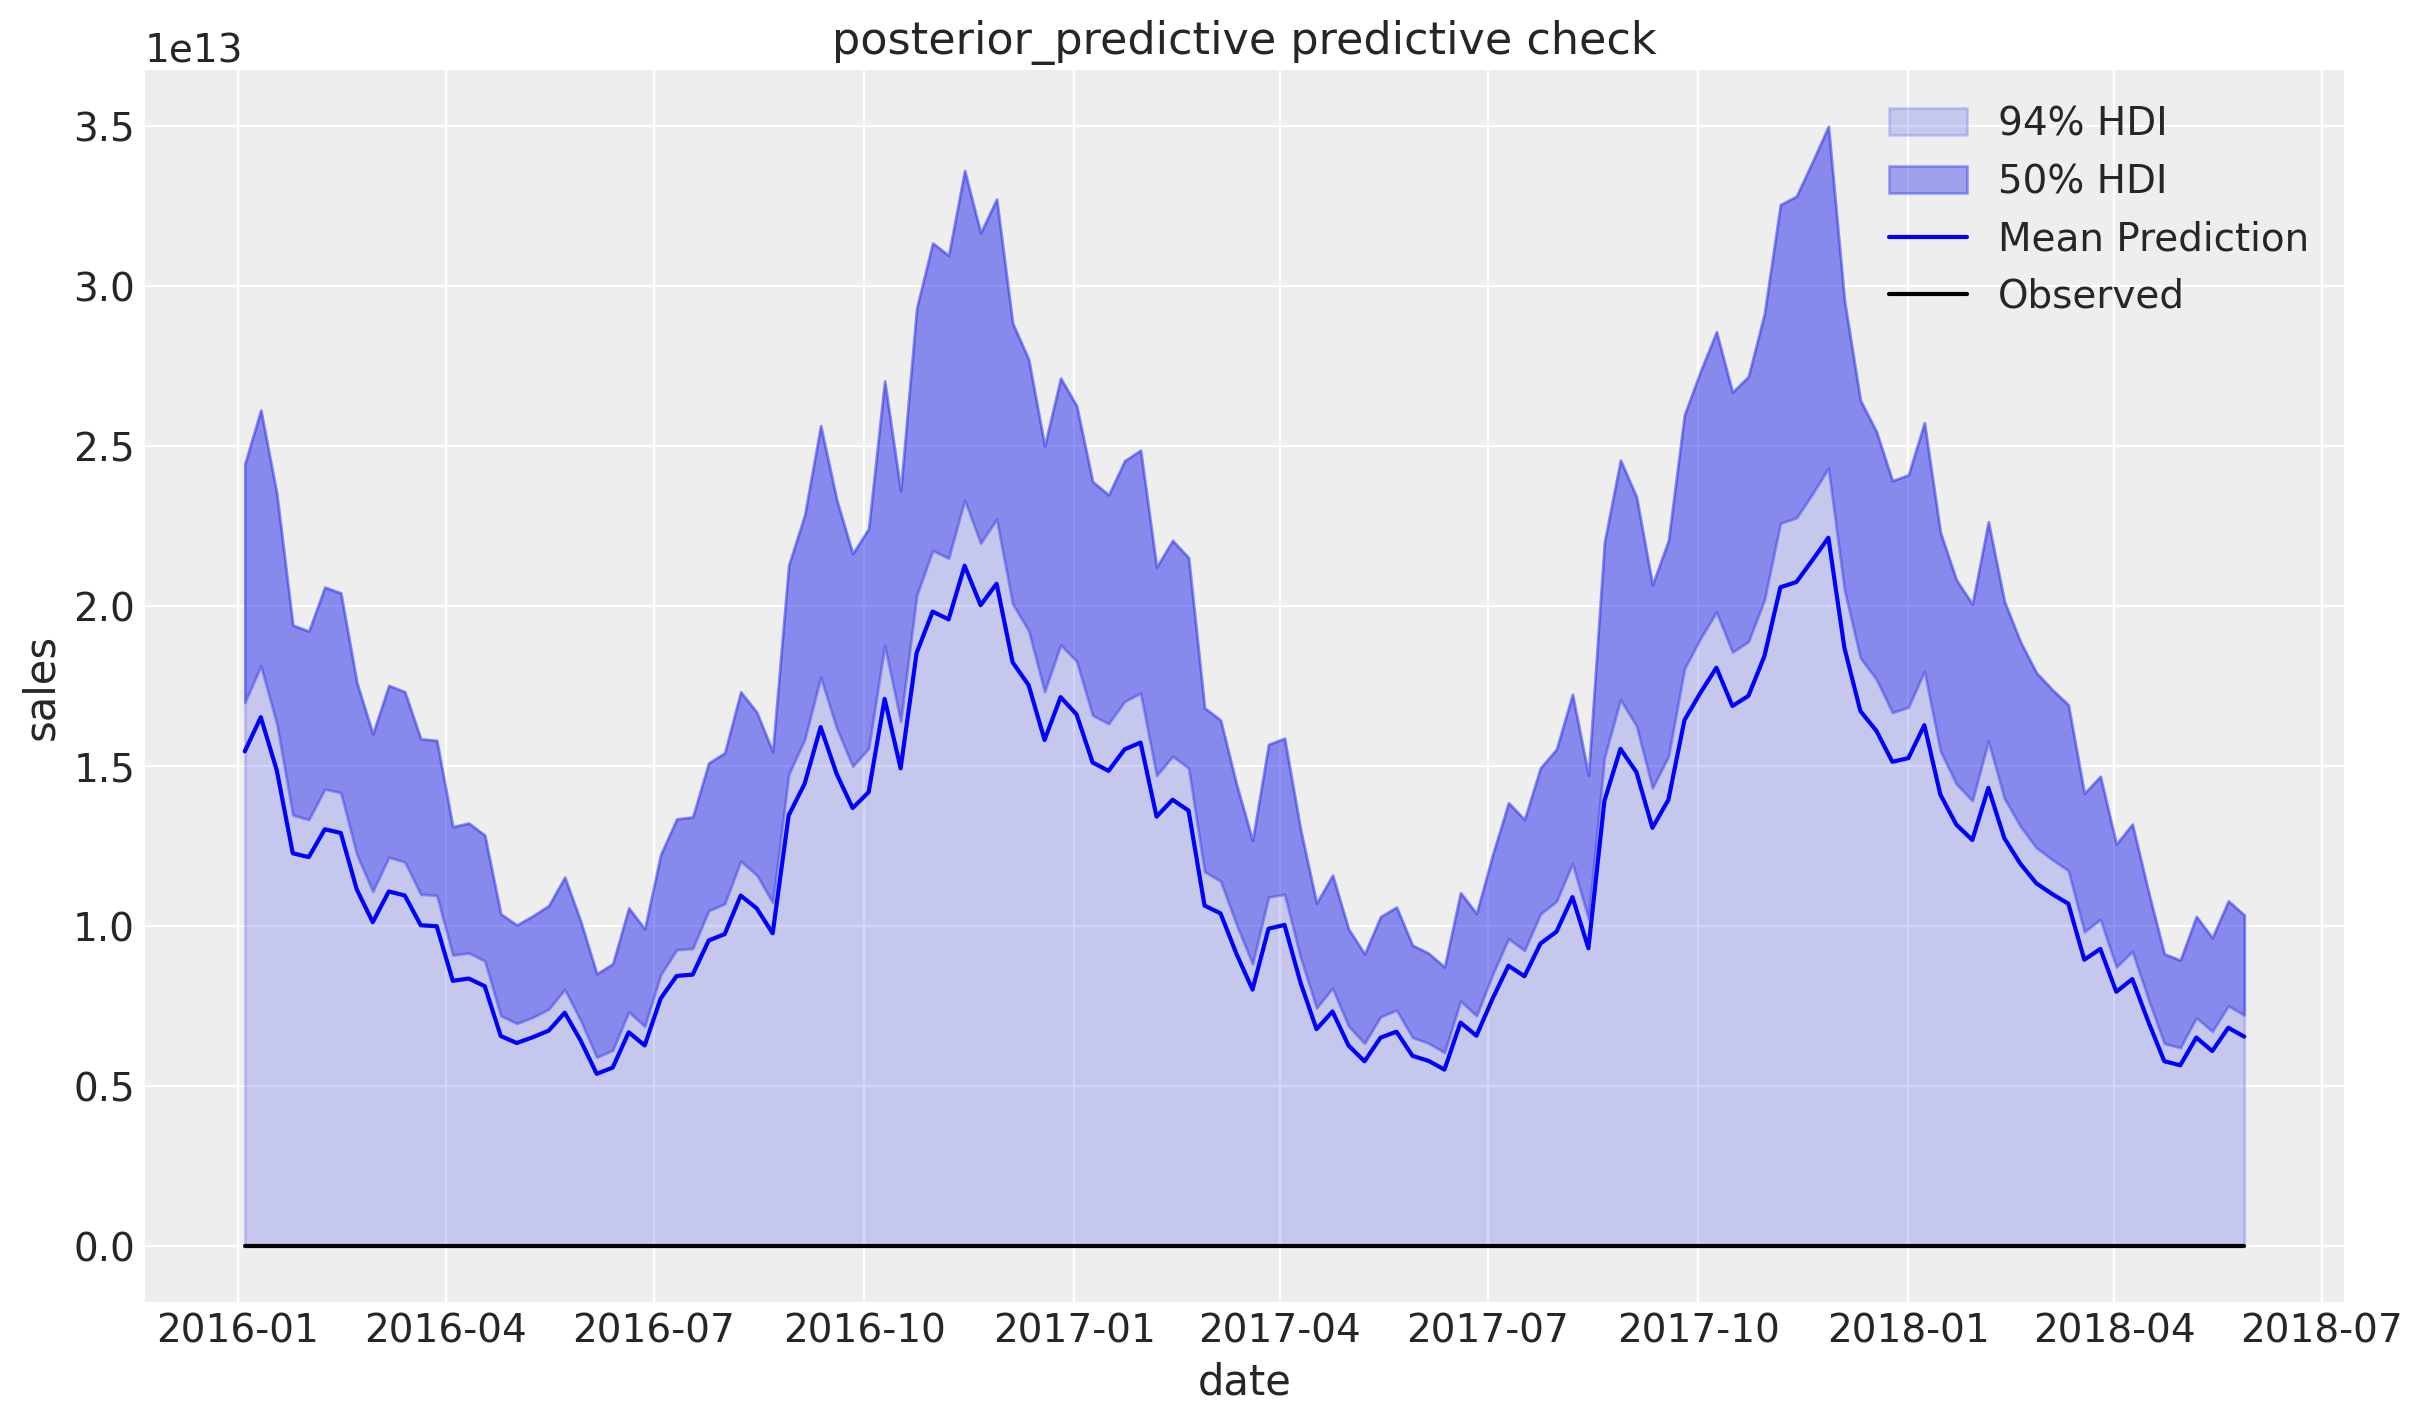

In [24]:
mmm.sample_posterior_predictive(X_train, extend_idata=True, combined=True)
fig = mmm.plot_posterior_predictive(original_scale=True)
fig.gca().set(xlabel="date", ylabel="sales");

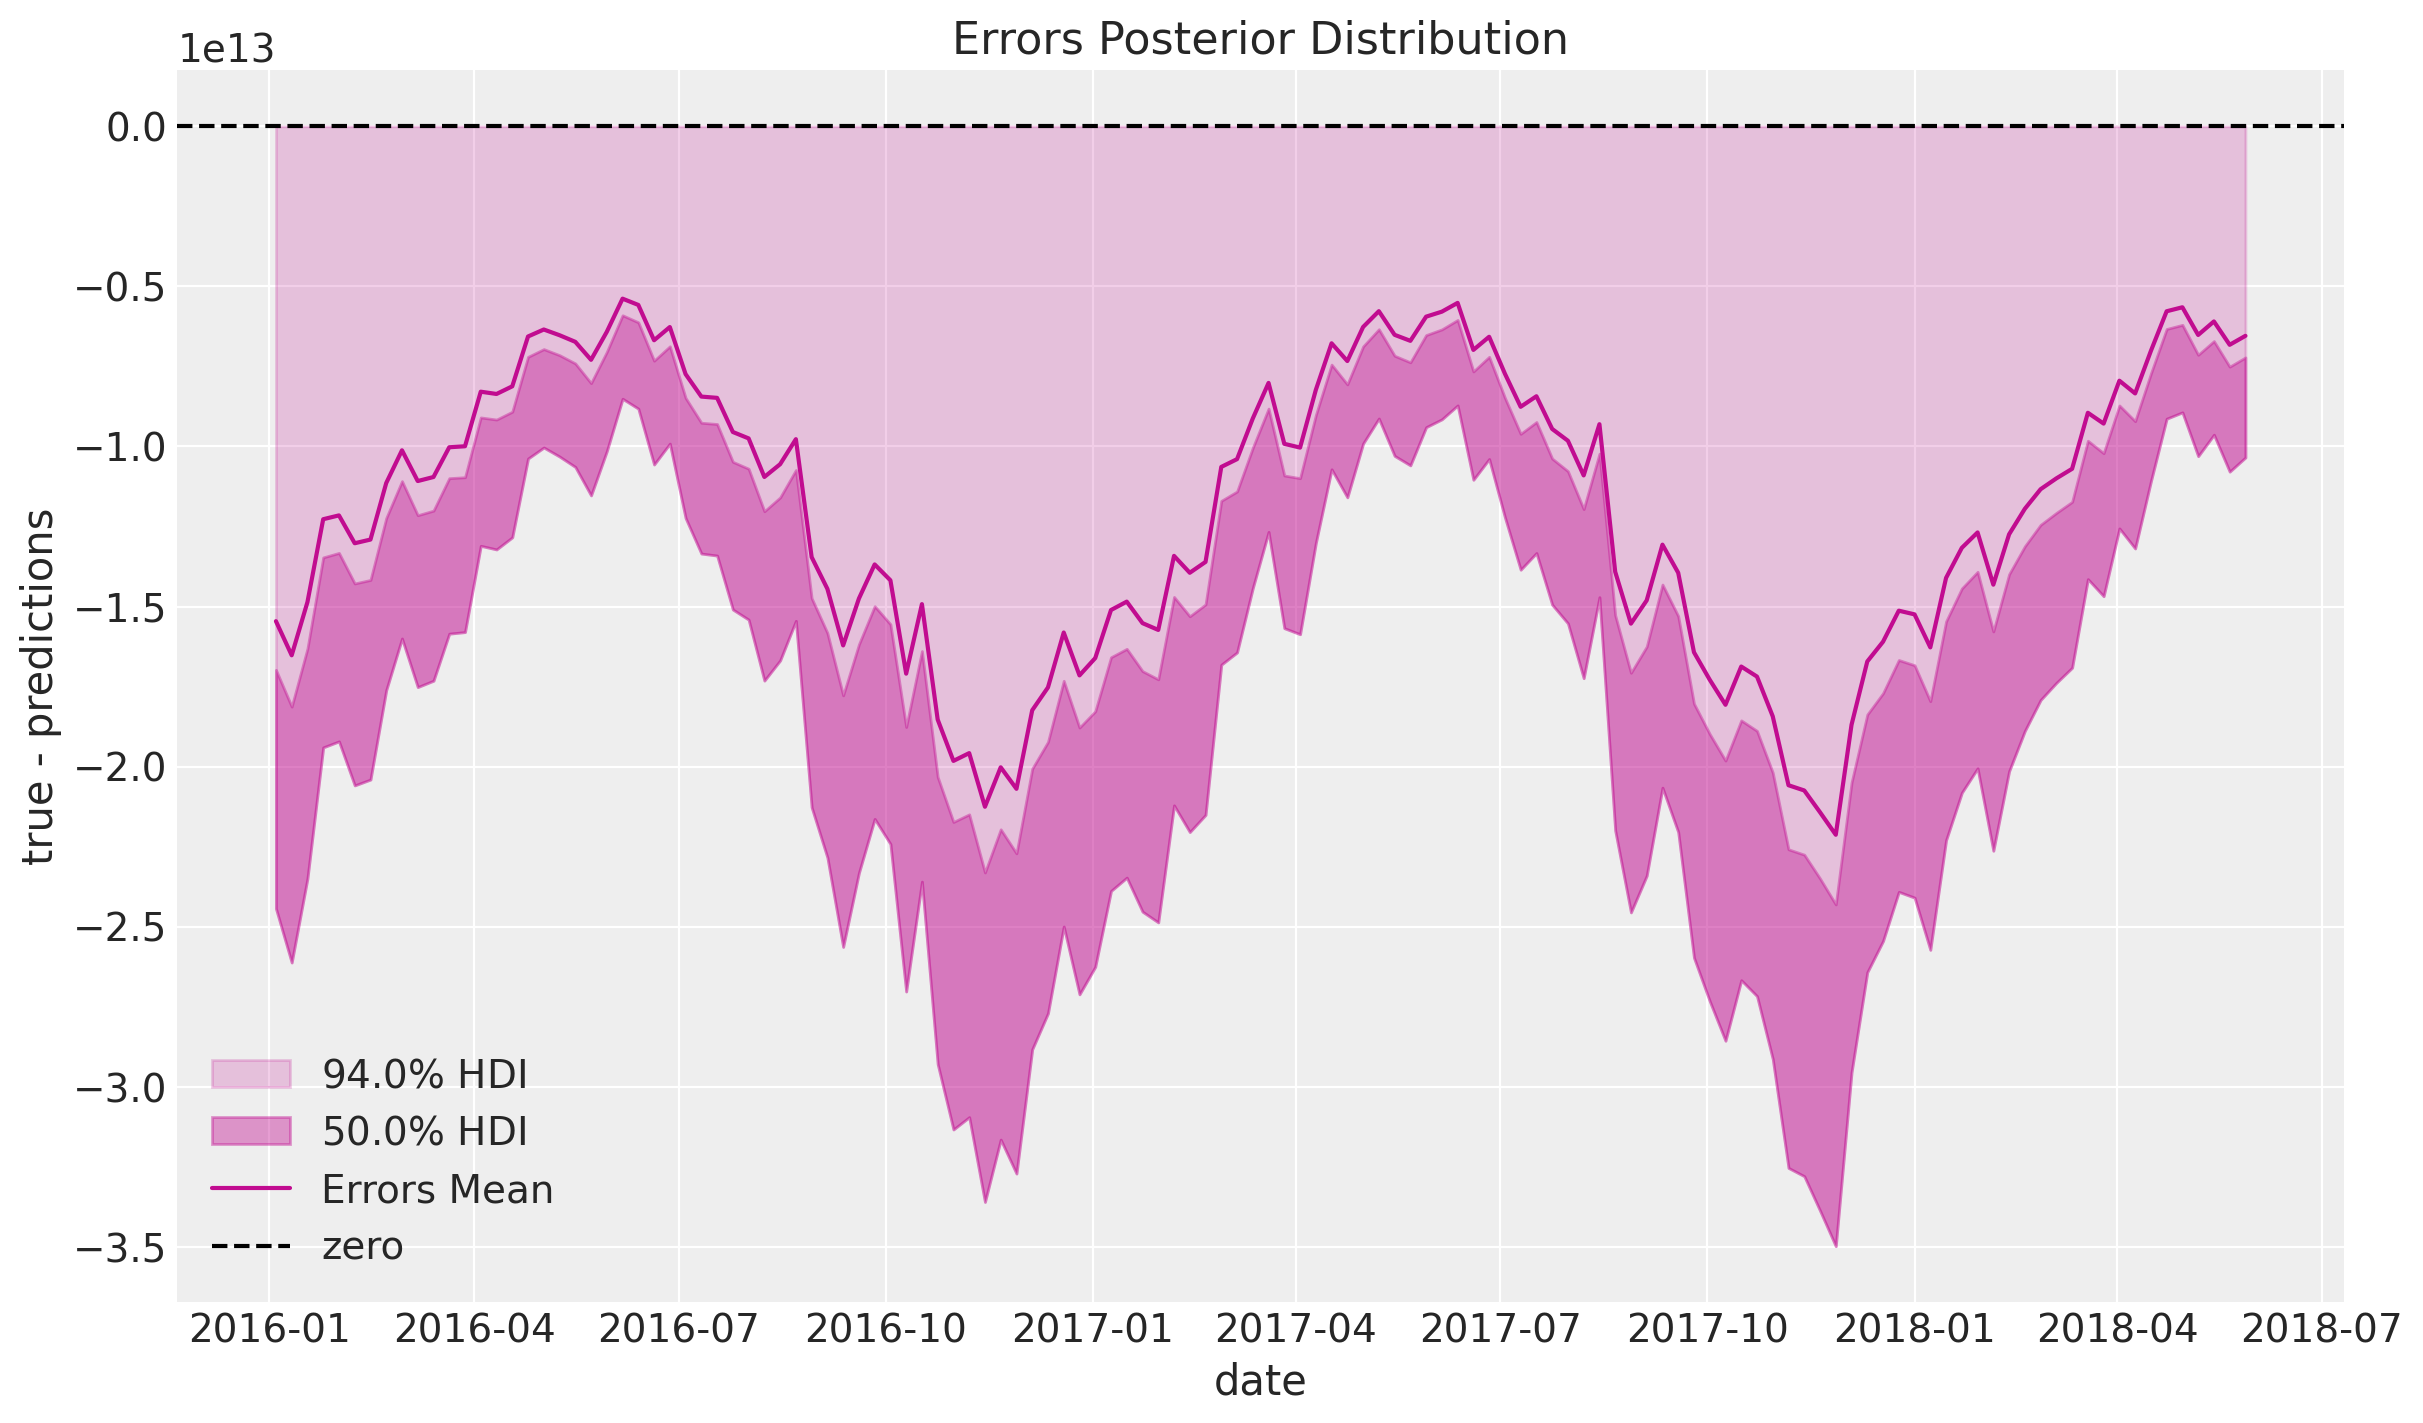

In [25]:
mmm.plot_errors(original_scale=True);

# 9. Media Deep Dive

## 9.1. Channel Contributions

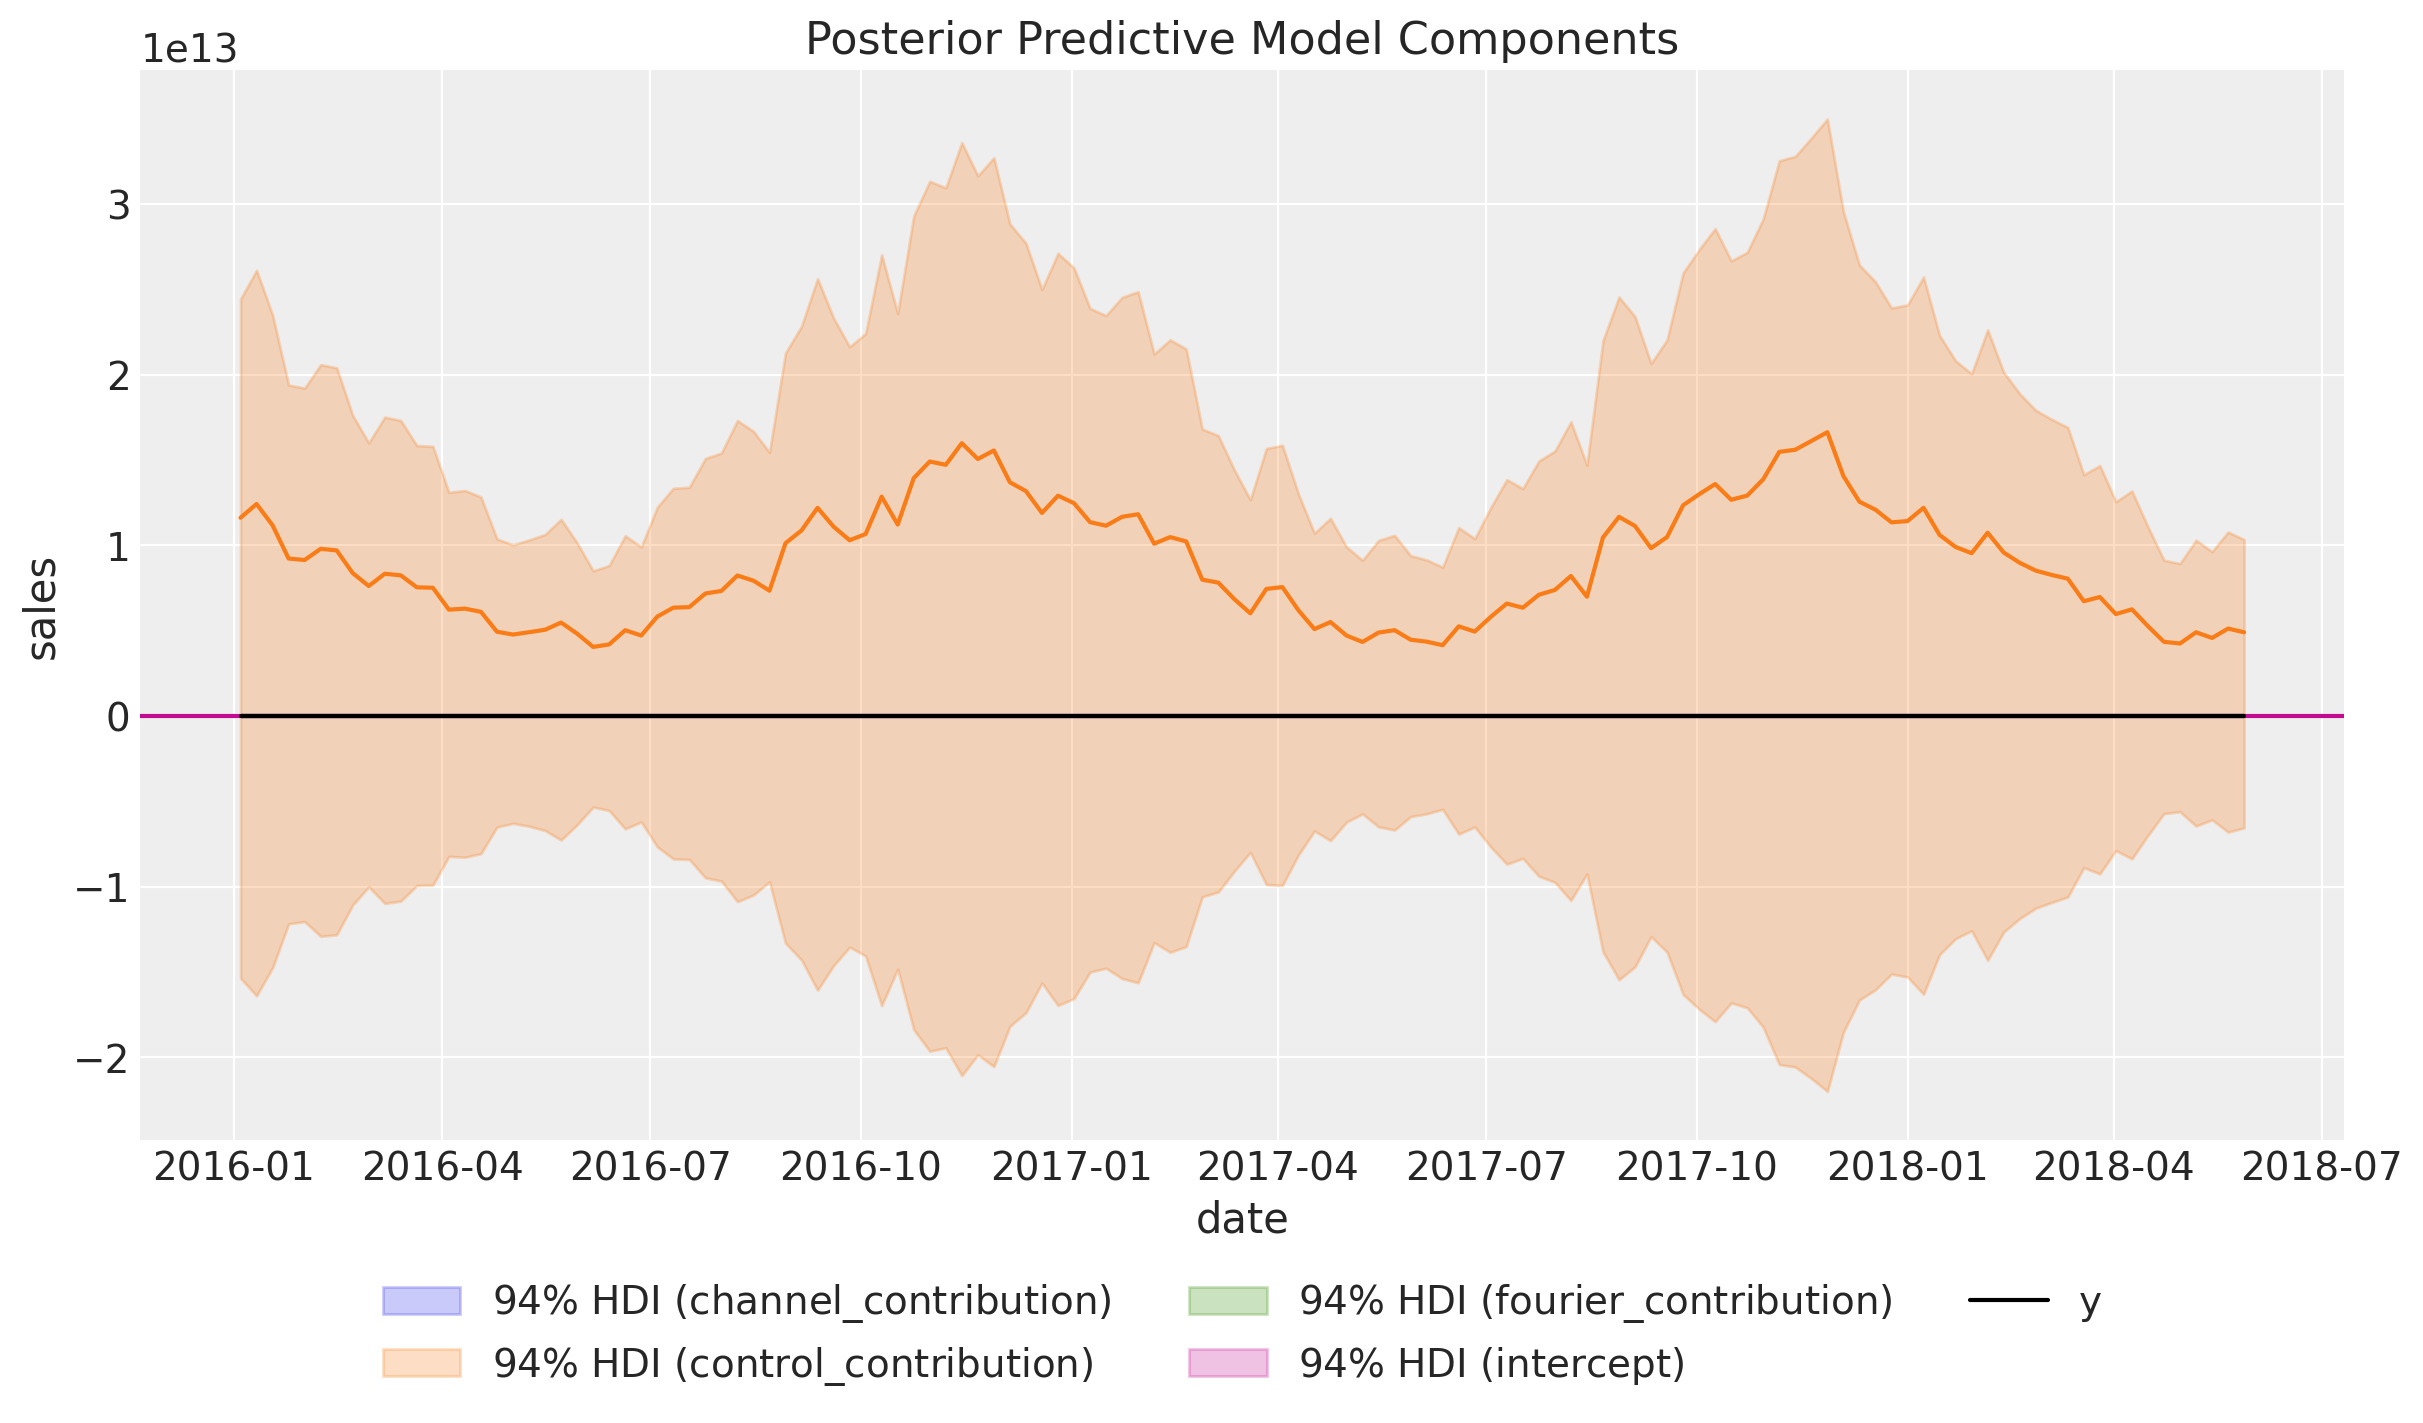

In [27]:
fig = mmm.plot_components_contributions(original_scale=True)
fig.gca().set(xlabel="date", ylabel="sales");

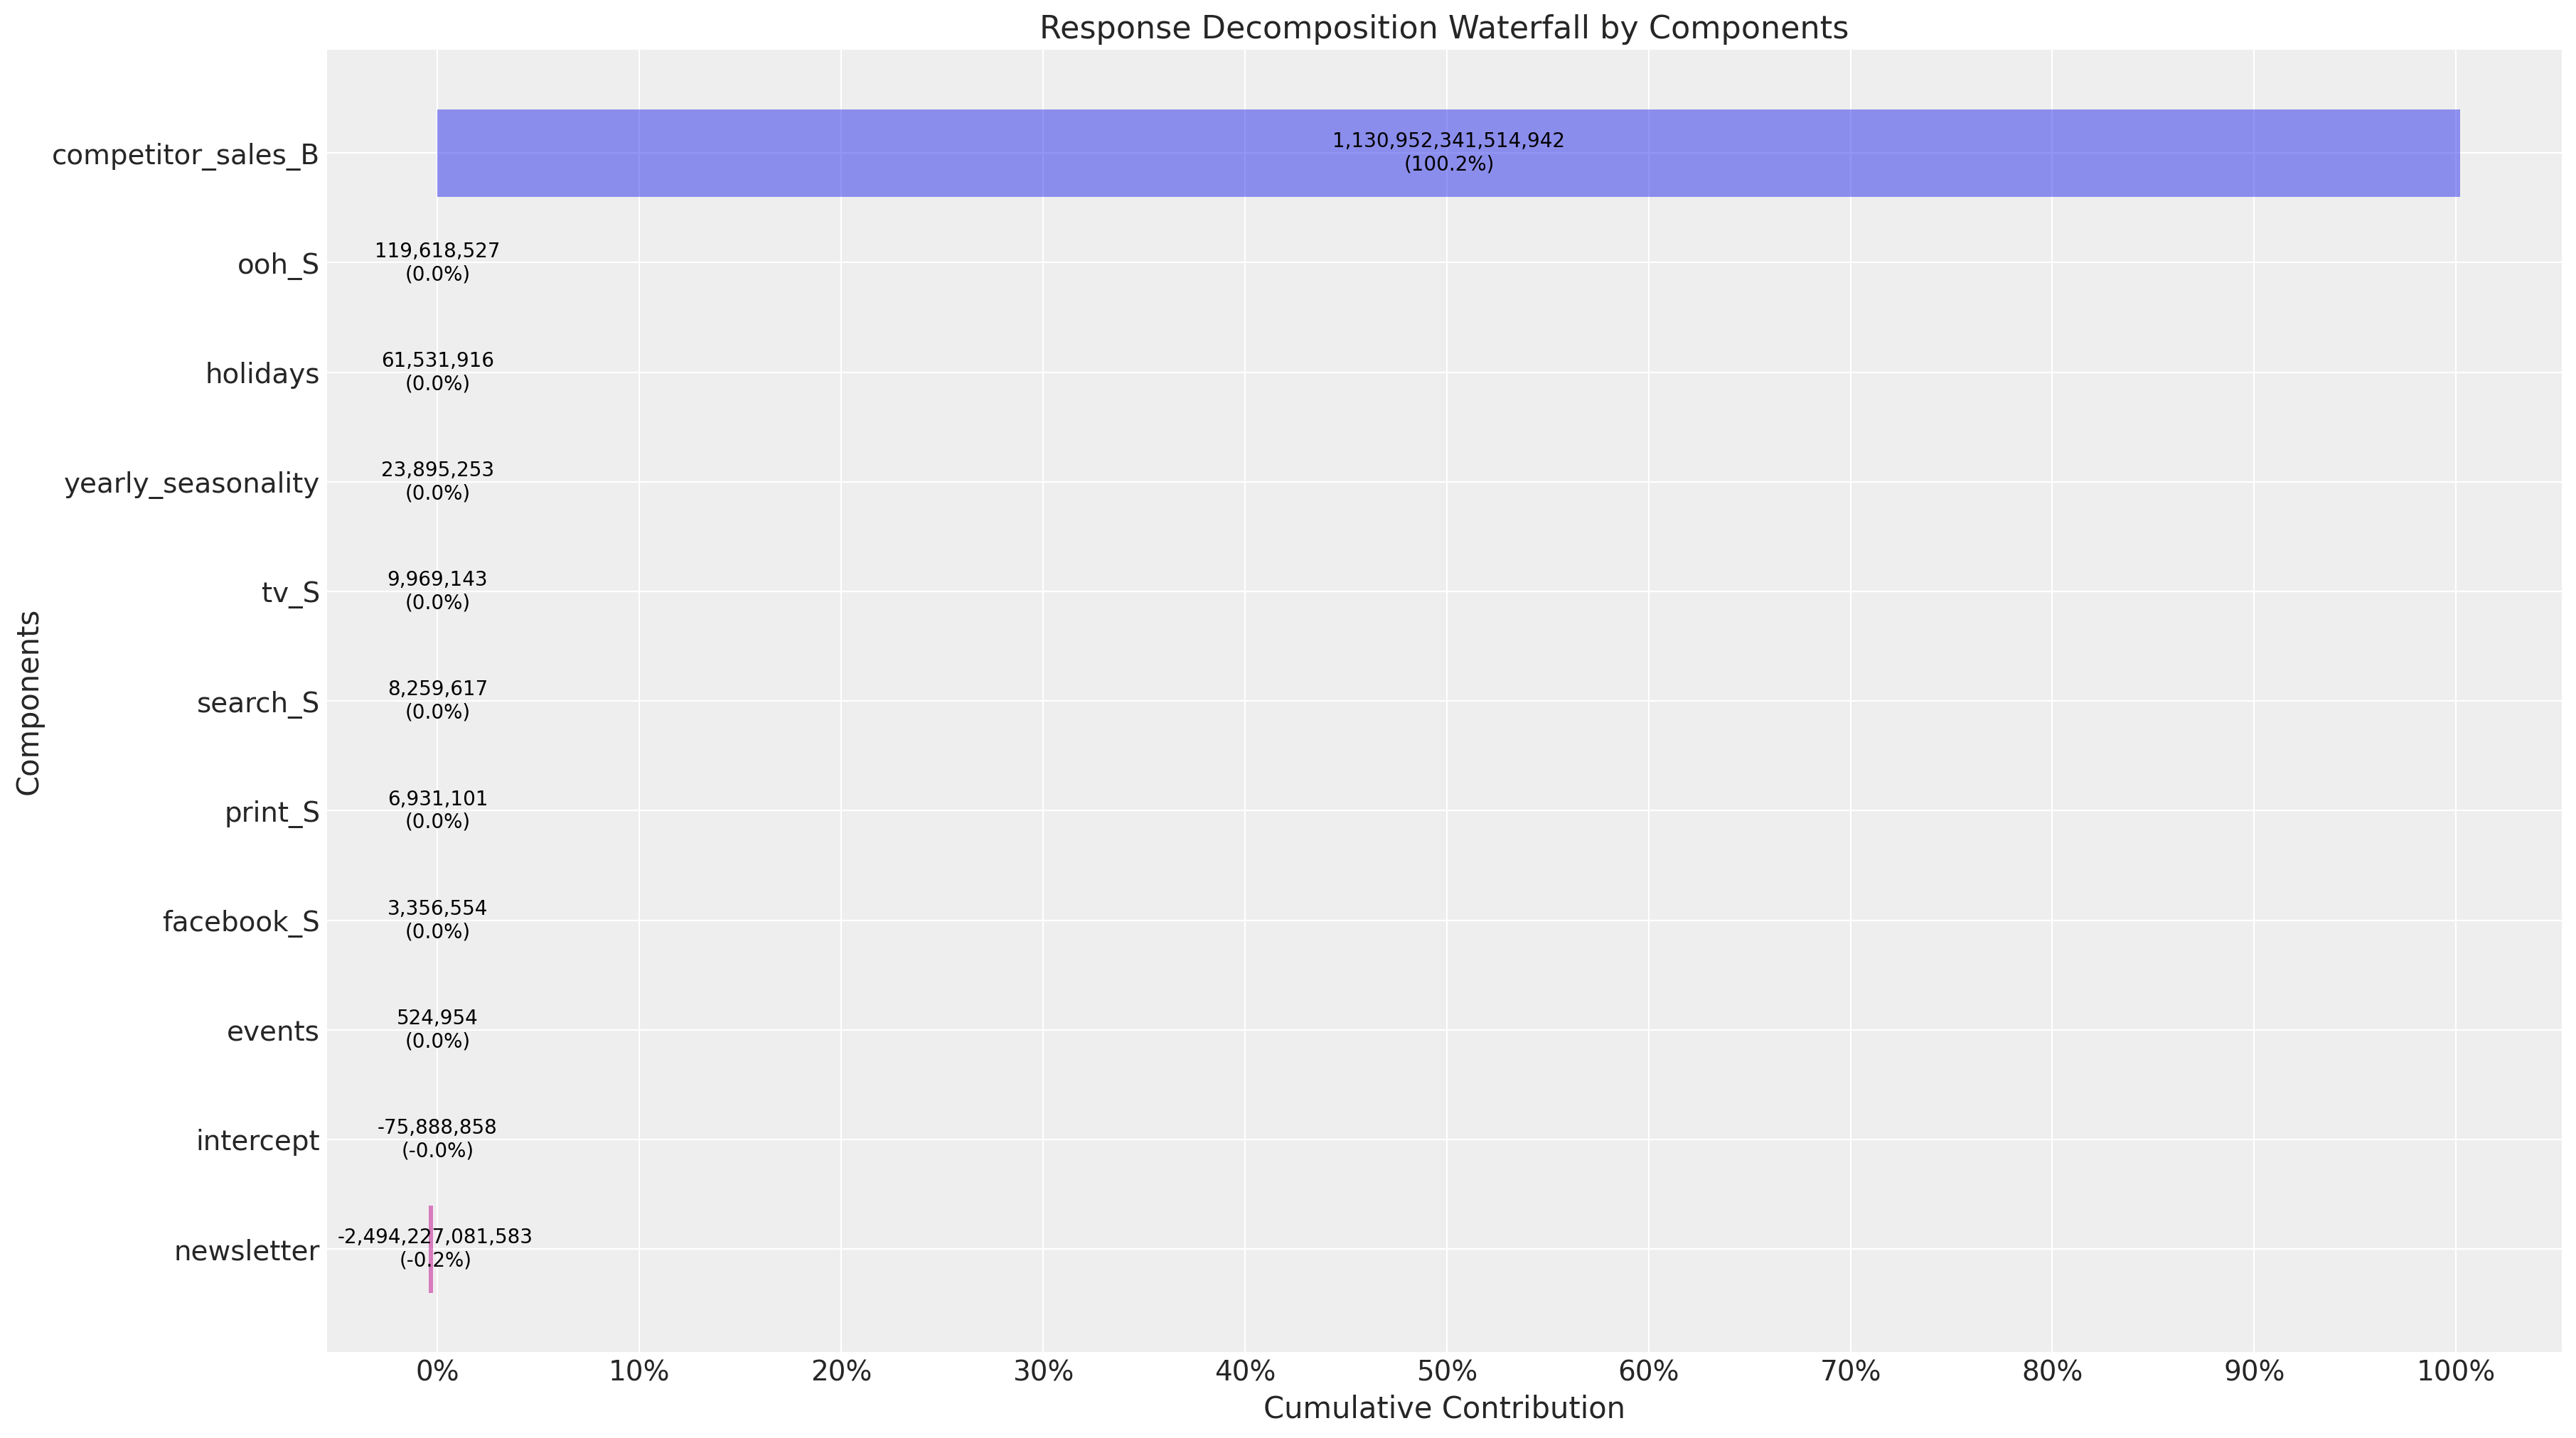

In [28]:
mmm.plot_waterfall_components_decomposition(figsize=(18, 10));

## 9.2. Saturation Curves

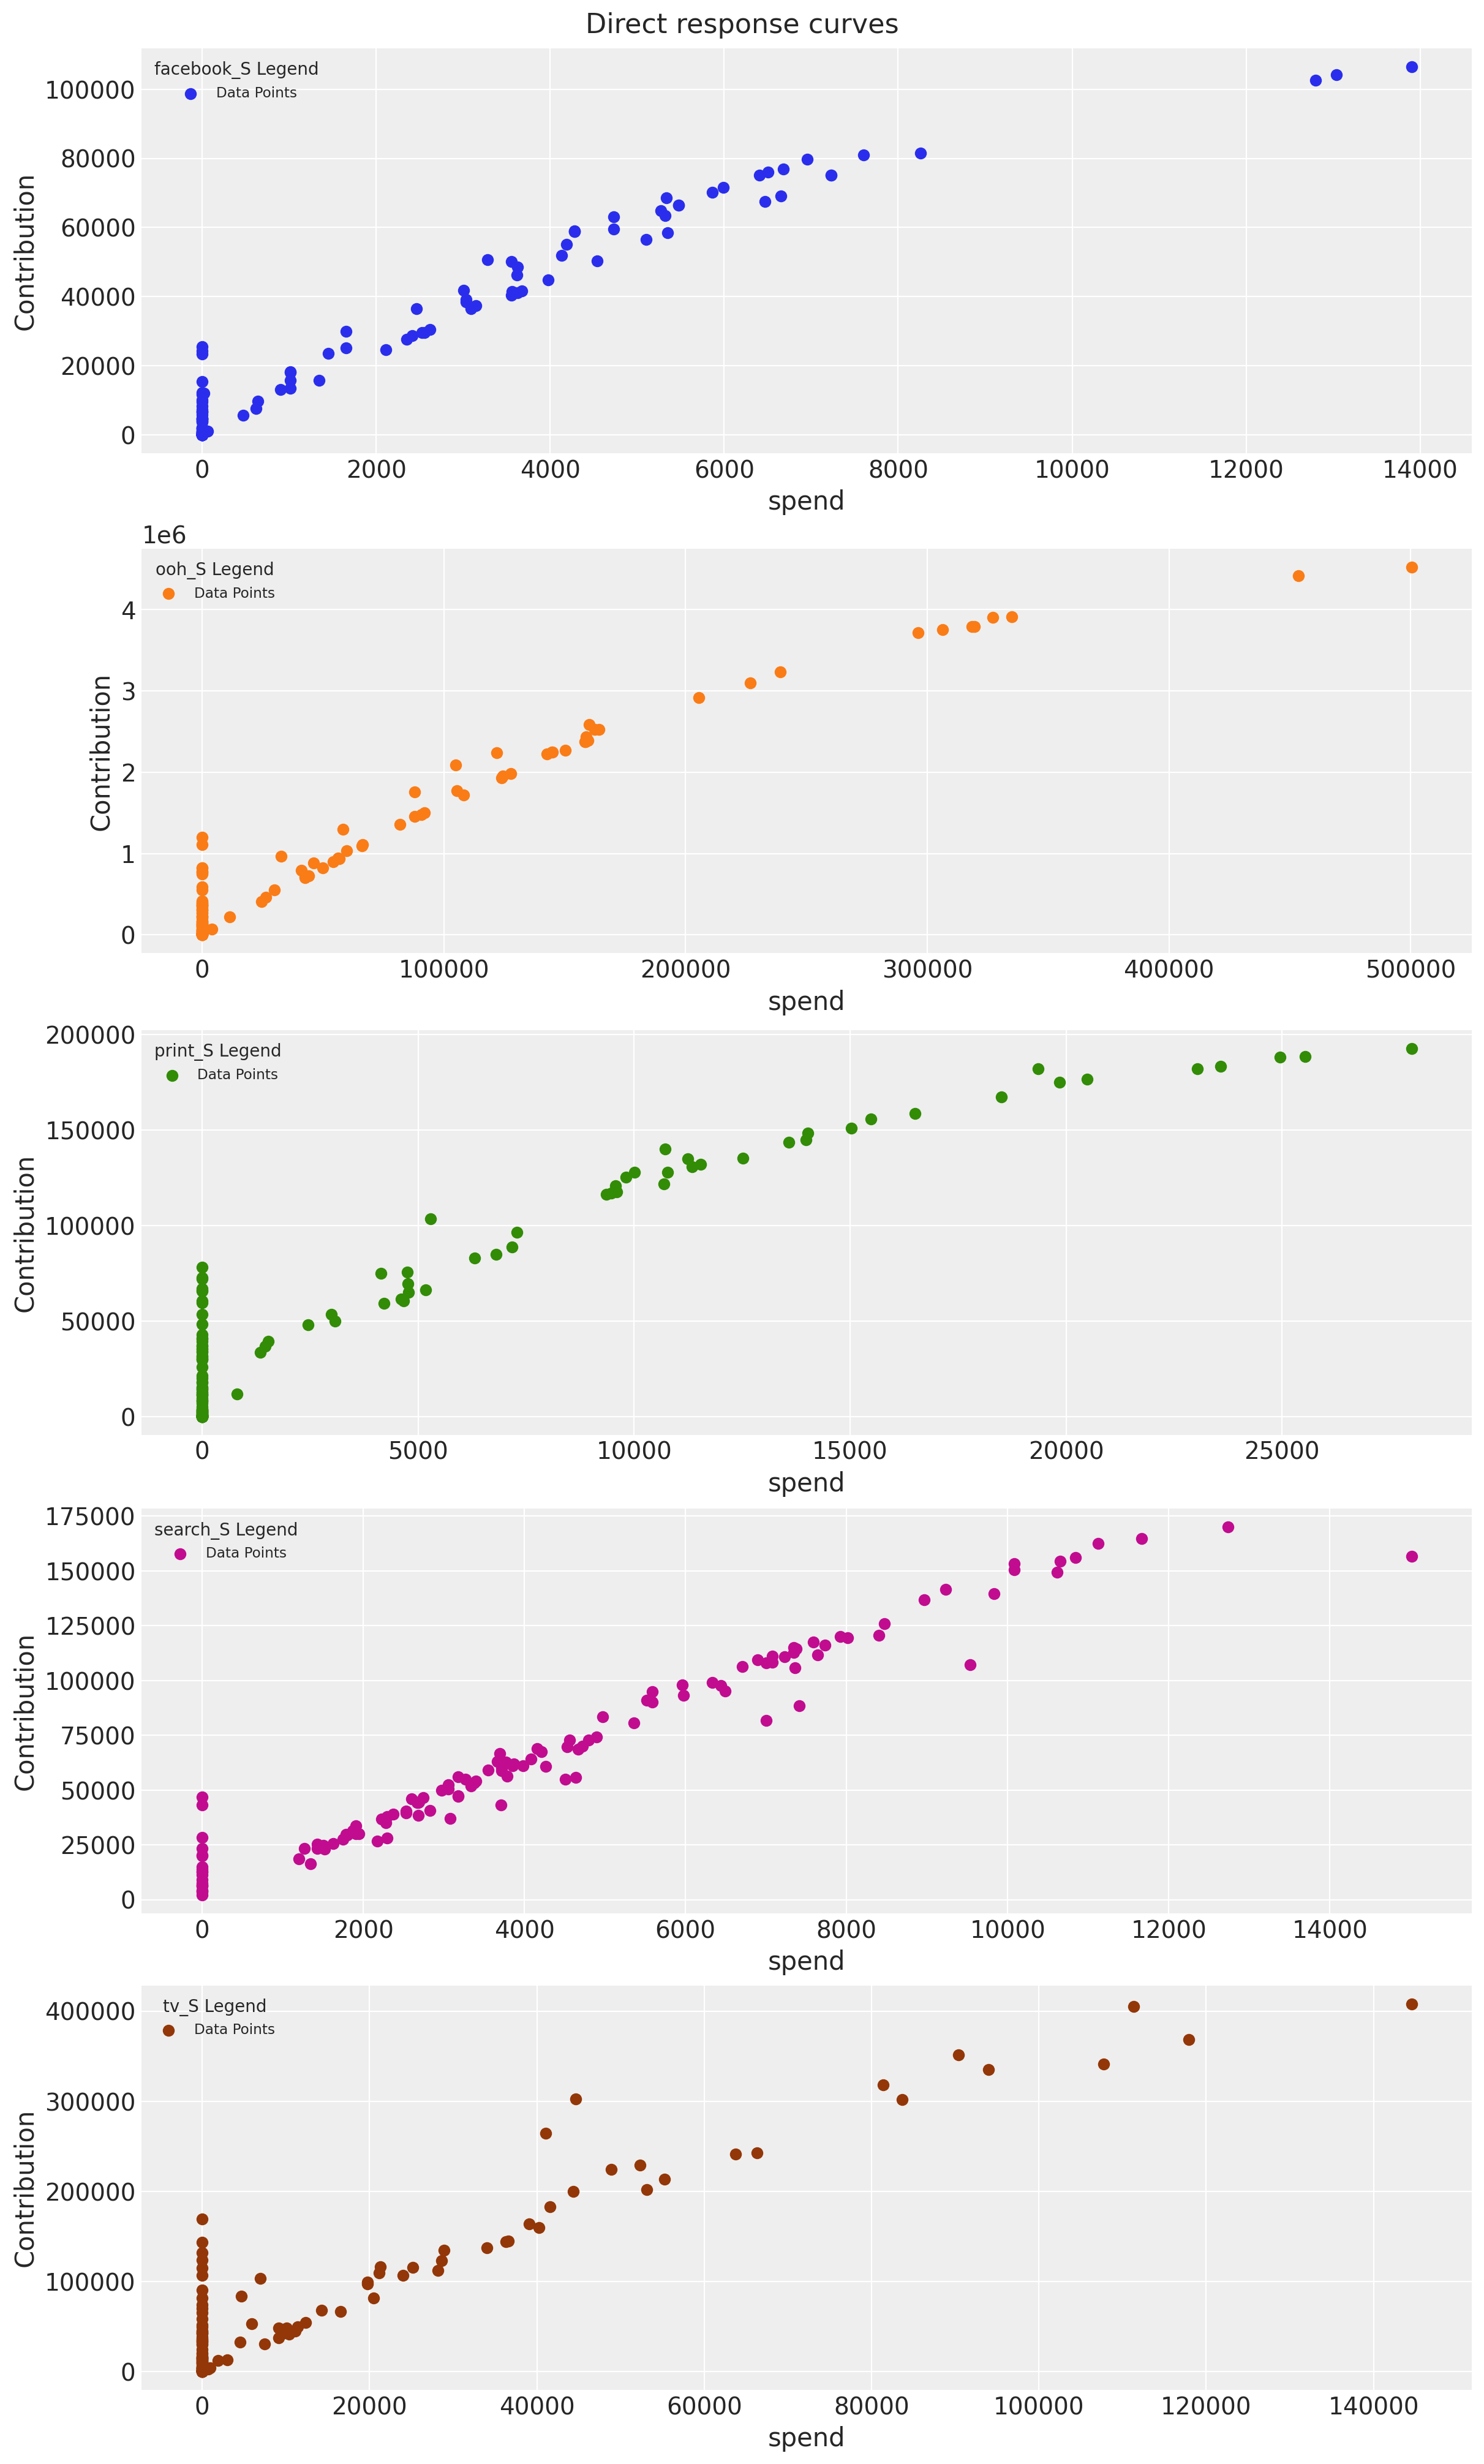

In [29]:
fig = mmm.plot_direct_contribution_curves()
[ax.set(xlabel="spend") for ax in fig.axes];

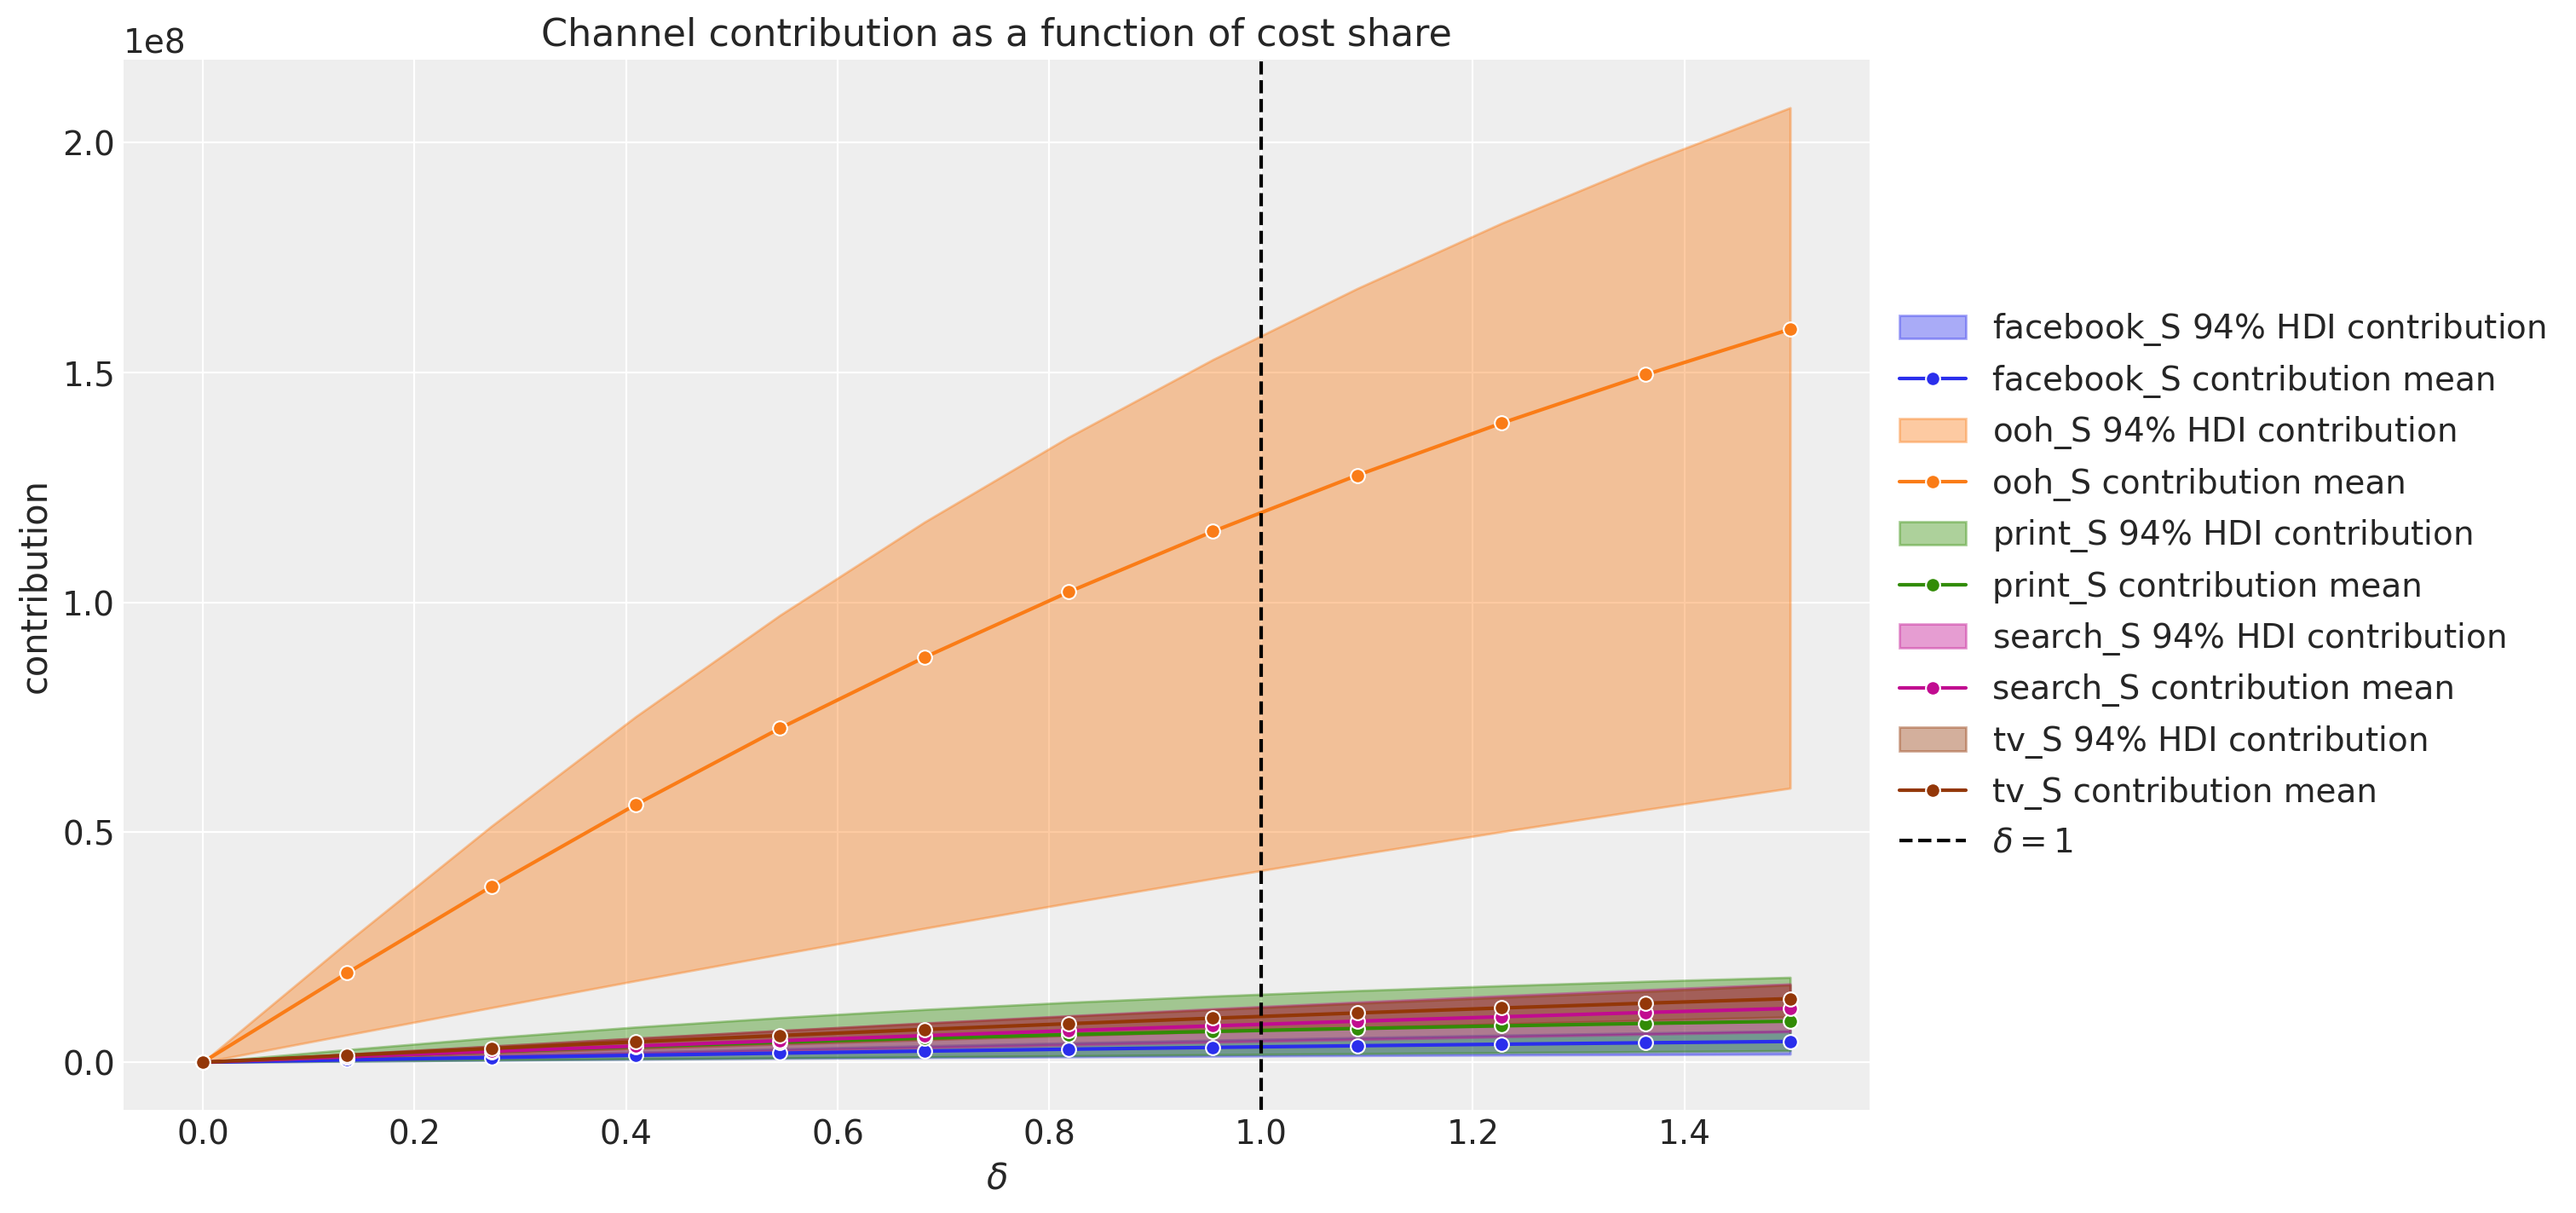

In [30]:
mmm.plot_channel_contribution_grid(start=0, stop=1.5, num=12, figsize=(15, 7));

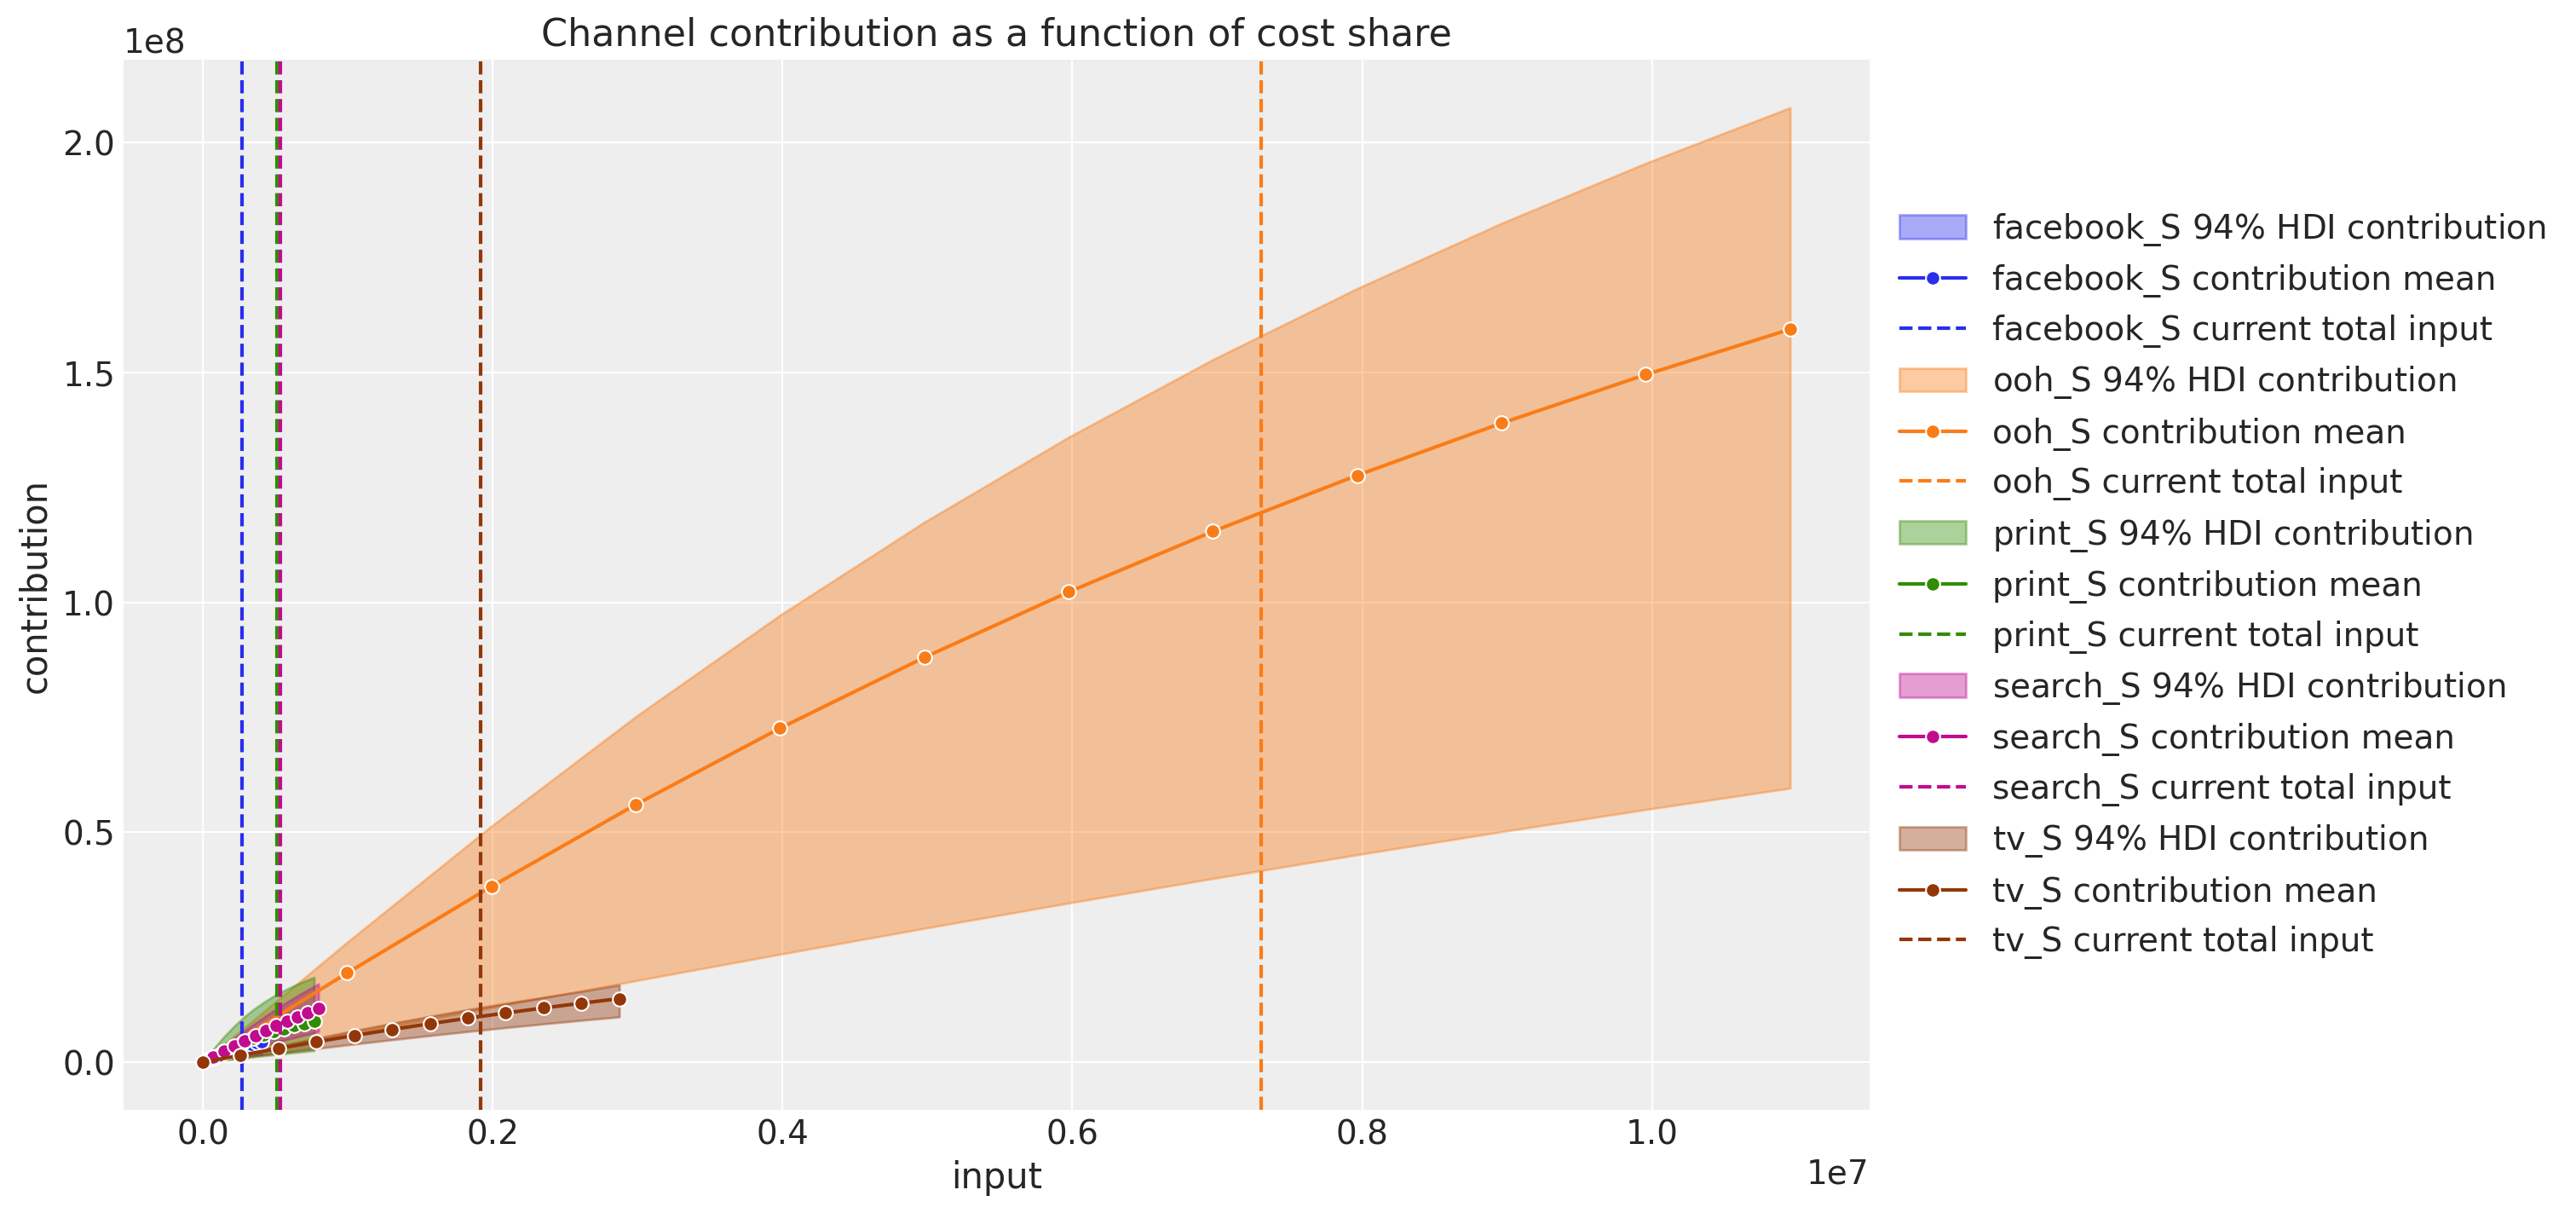

In [31]:
mmm.plot_channel_contribution_grid(
    start=0, stop=1.5, num=12, absolute_xrange=True, figsize=(15, 7)
);

## 9.3. Return on Ads Spend (ROAS)

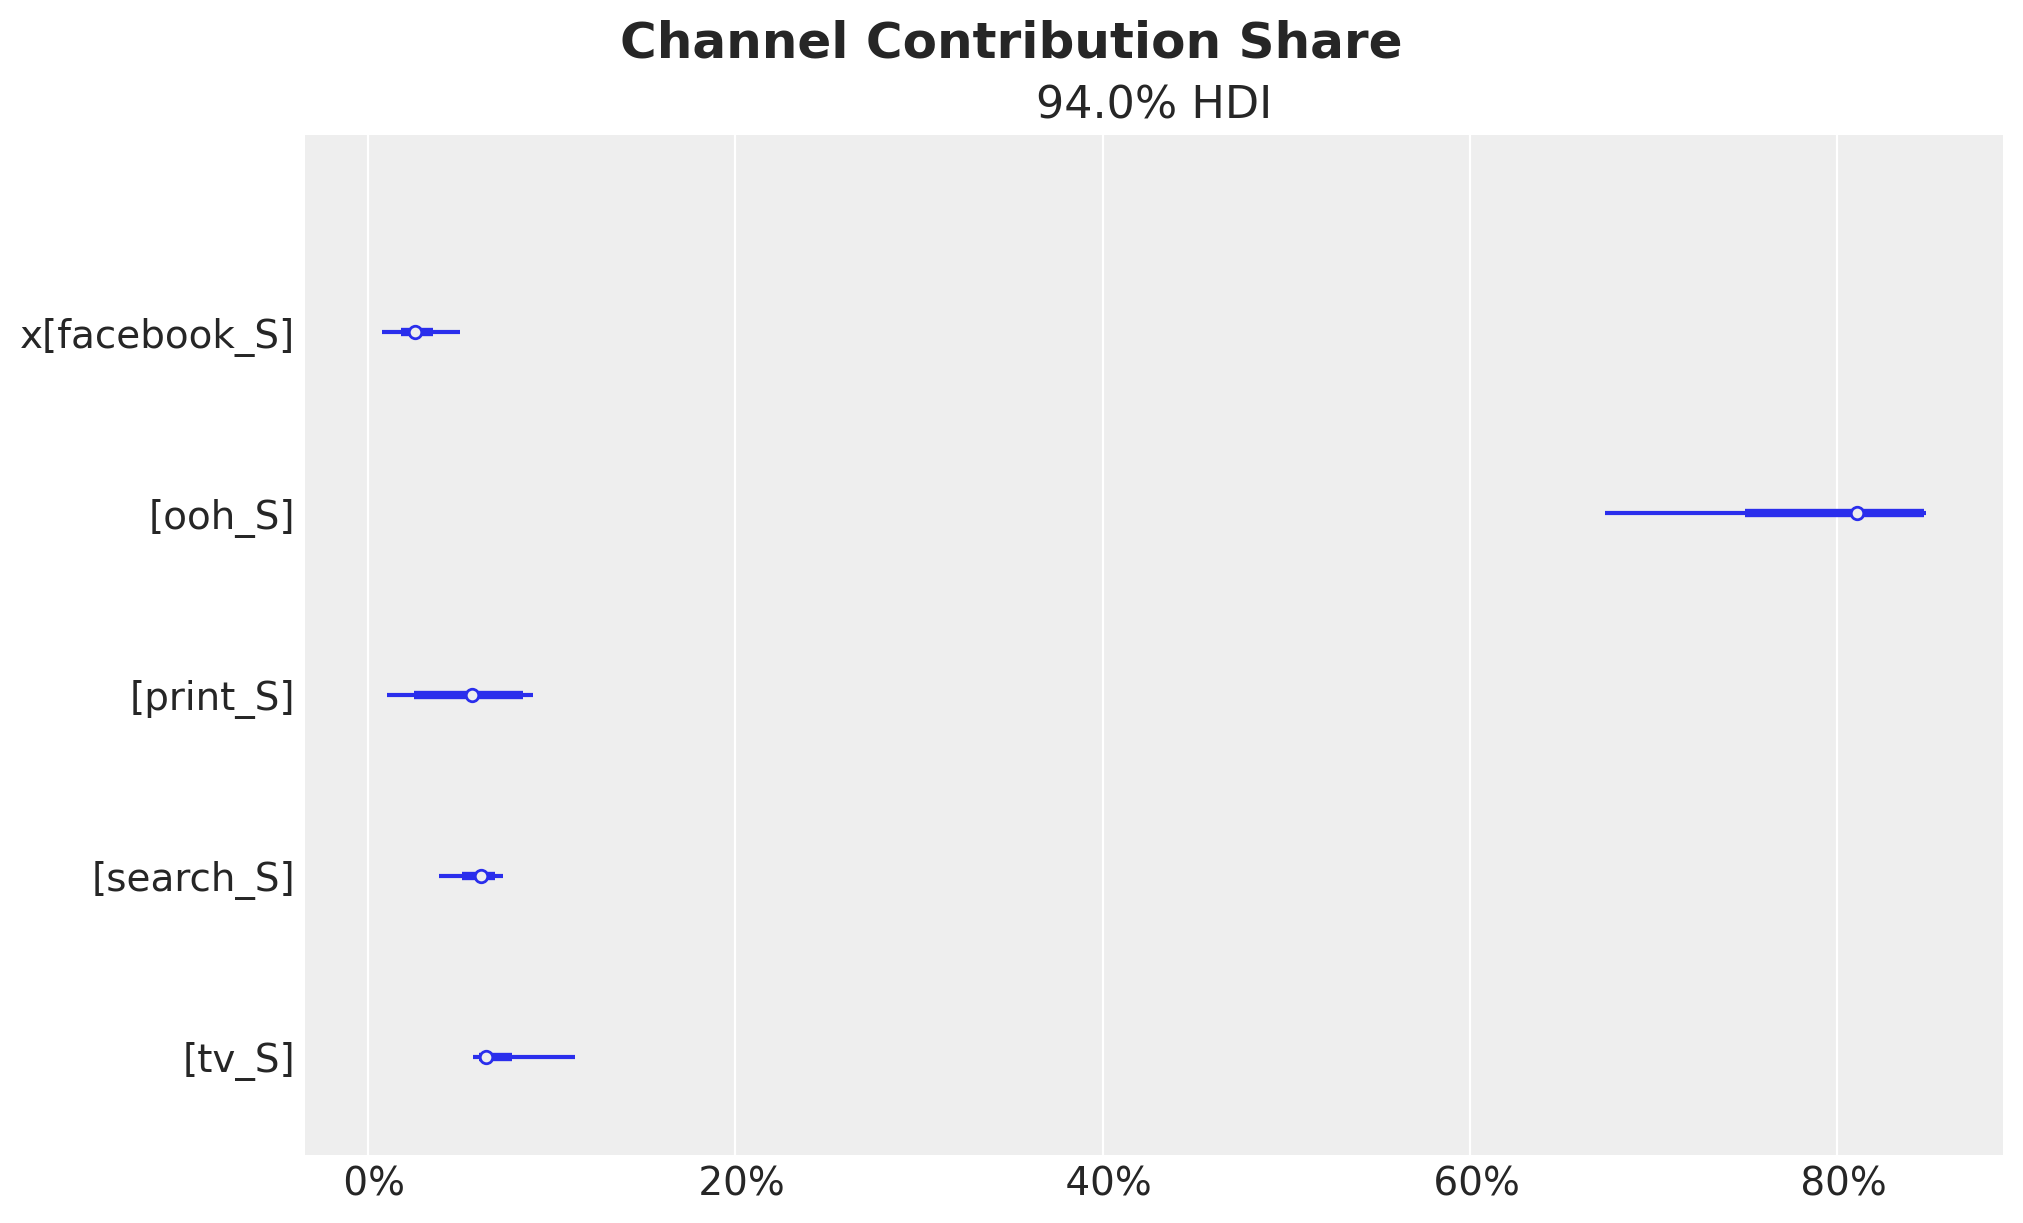

In [32]:
fig = mmm.plot_channel_contribution_share_hdi(figsize=(10, 6))
fig.suptitle("Channel Contribution Share", fontsize=18, fontweight="bold");

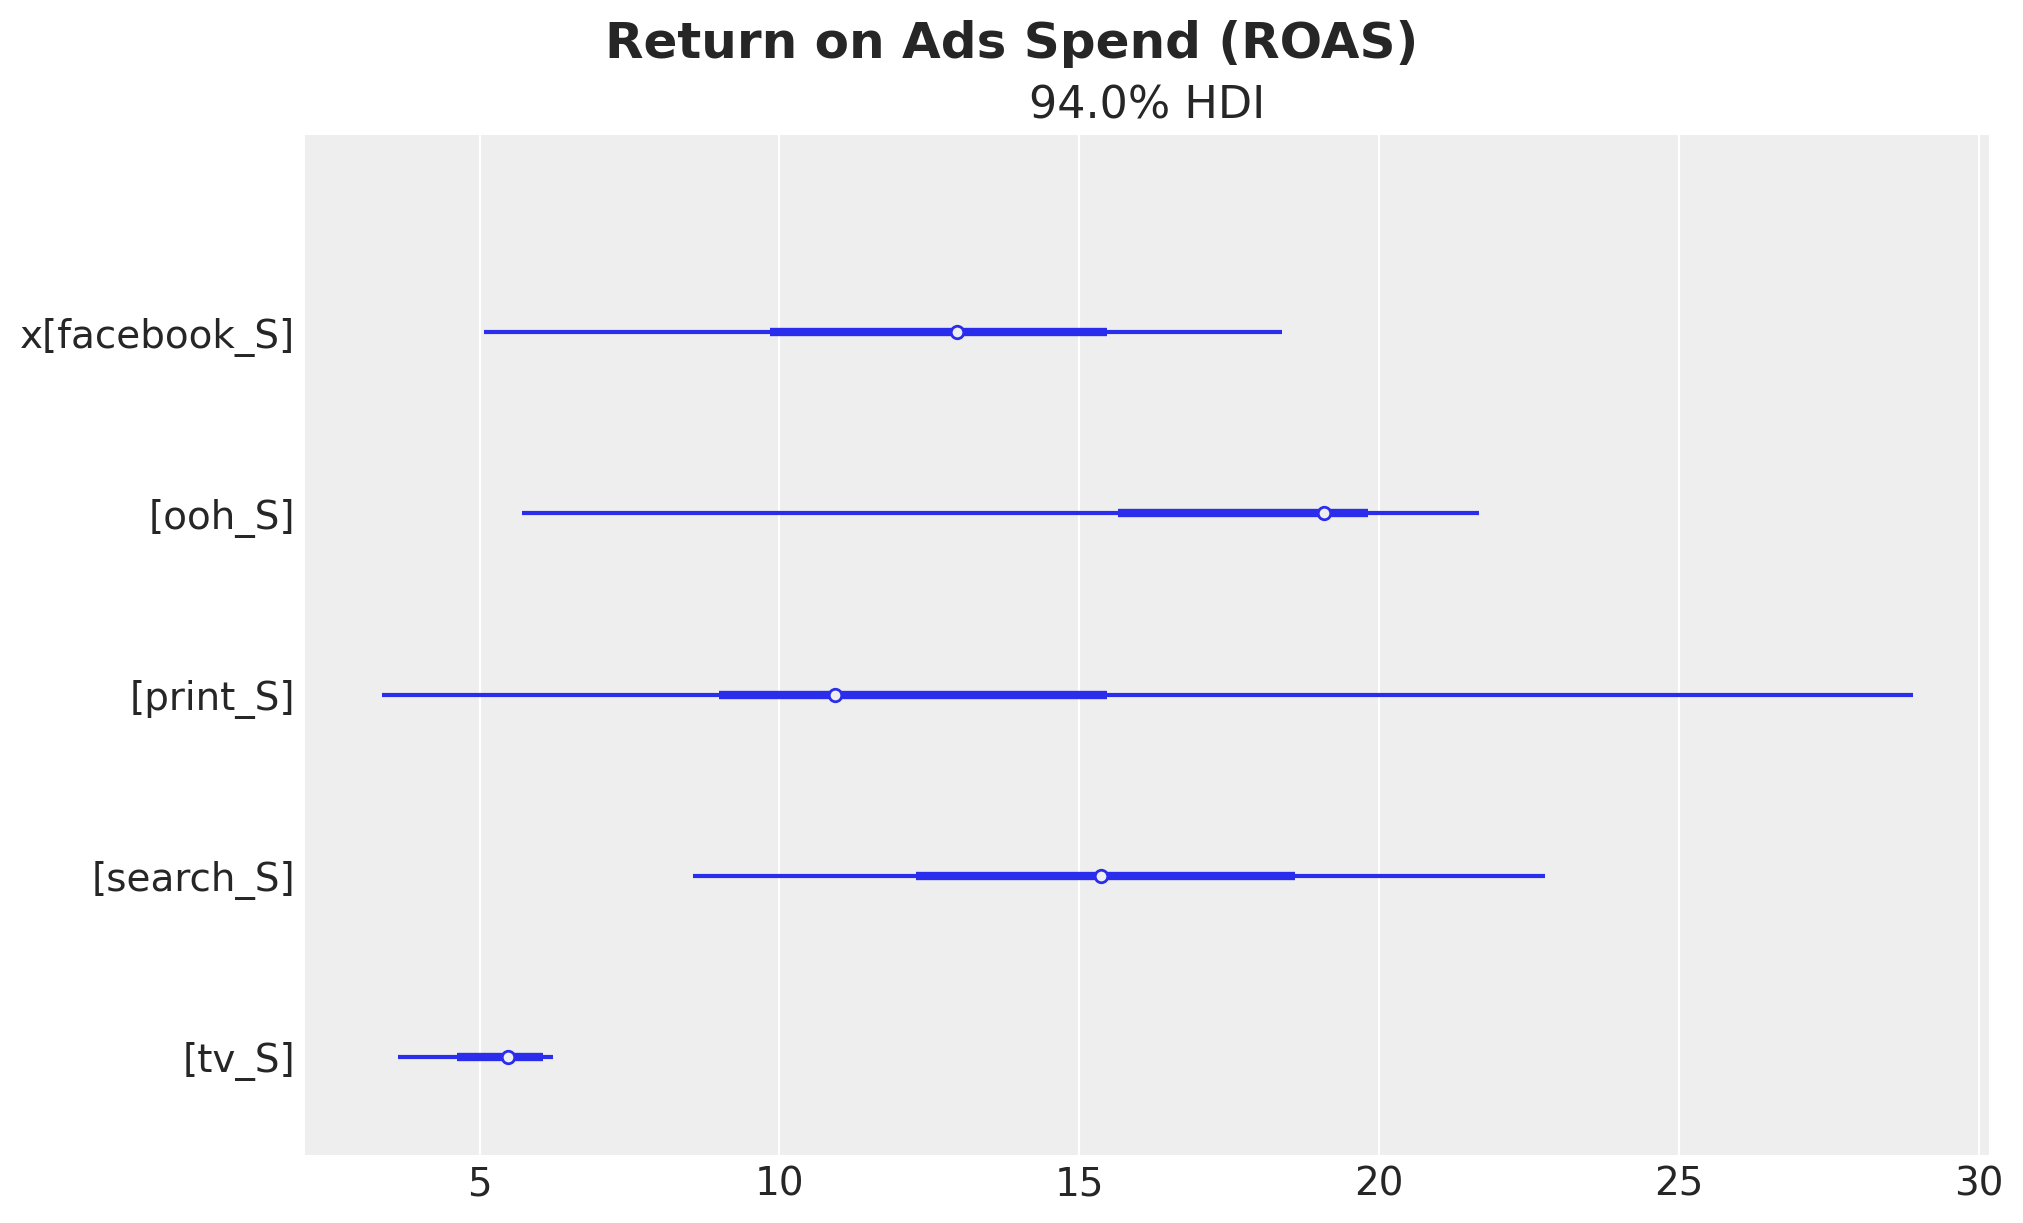

In [35]:
# Get the channel contributions on the original scale
channel_contribution_original_scale = mmm.compute_channel_contribution_original_scale()

# Sum the contributions over the whole training period
spend_sum = X_train[channel_cols].sum().to_numpy()
spend_sum = spend_sum[
    np.newaxis, np.newaxis, :
]  # We need these extra dimensions to broadcast the spend sum to the shape of the contributions.

# Compute the ROAS as the ratio of the mean contribution and the spend for each channel
roas_samples = channel_contribution_original_scale.sum(dim="date") / spend_sum

# Plot the ROAS
fig, ax = plt.subplots(figsize=(10, 6))
az.plot_forest(roas_samples, combined=True, ax=ax)
fig.suptitle("Return on Ads Spend (ROAS)", fontsize=18, fontweight="bold");

## 9.4. ROAS and Contribution Share comparison

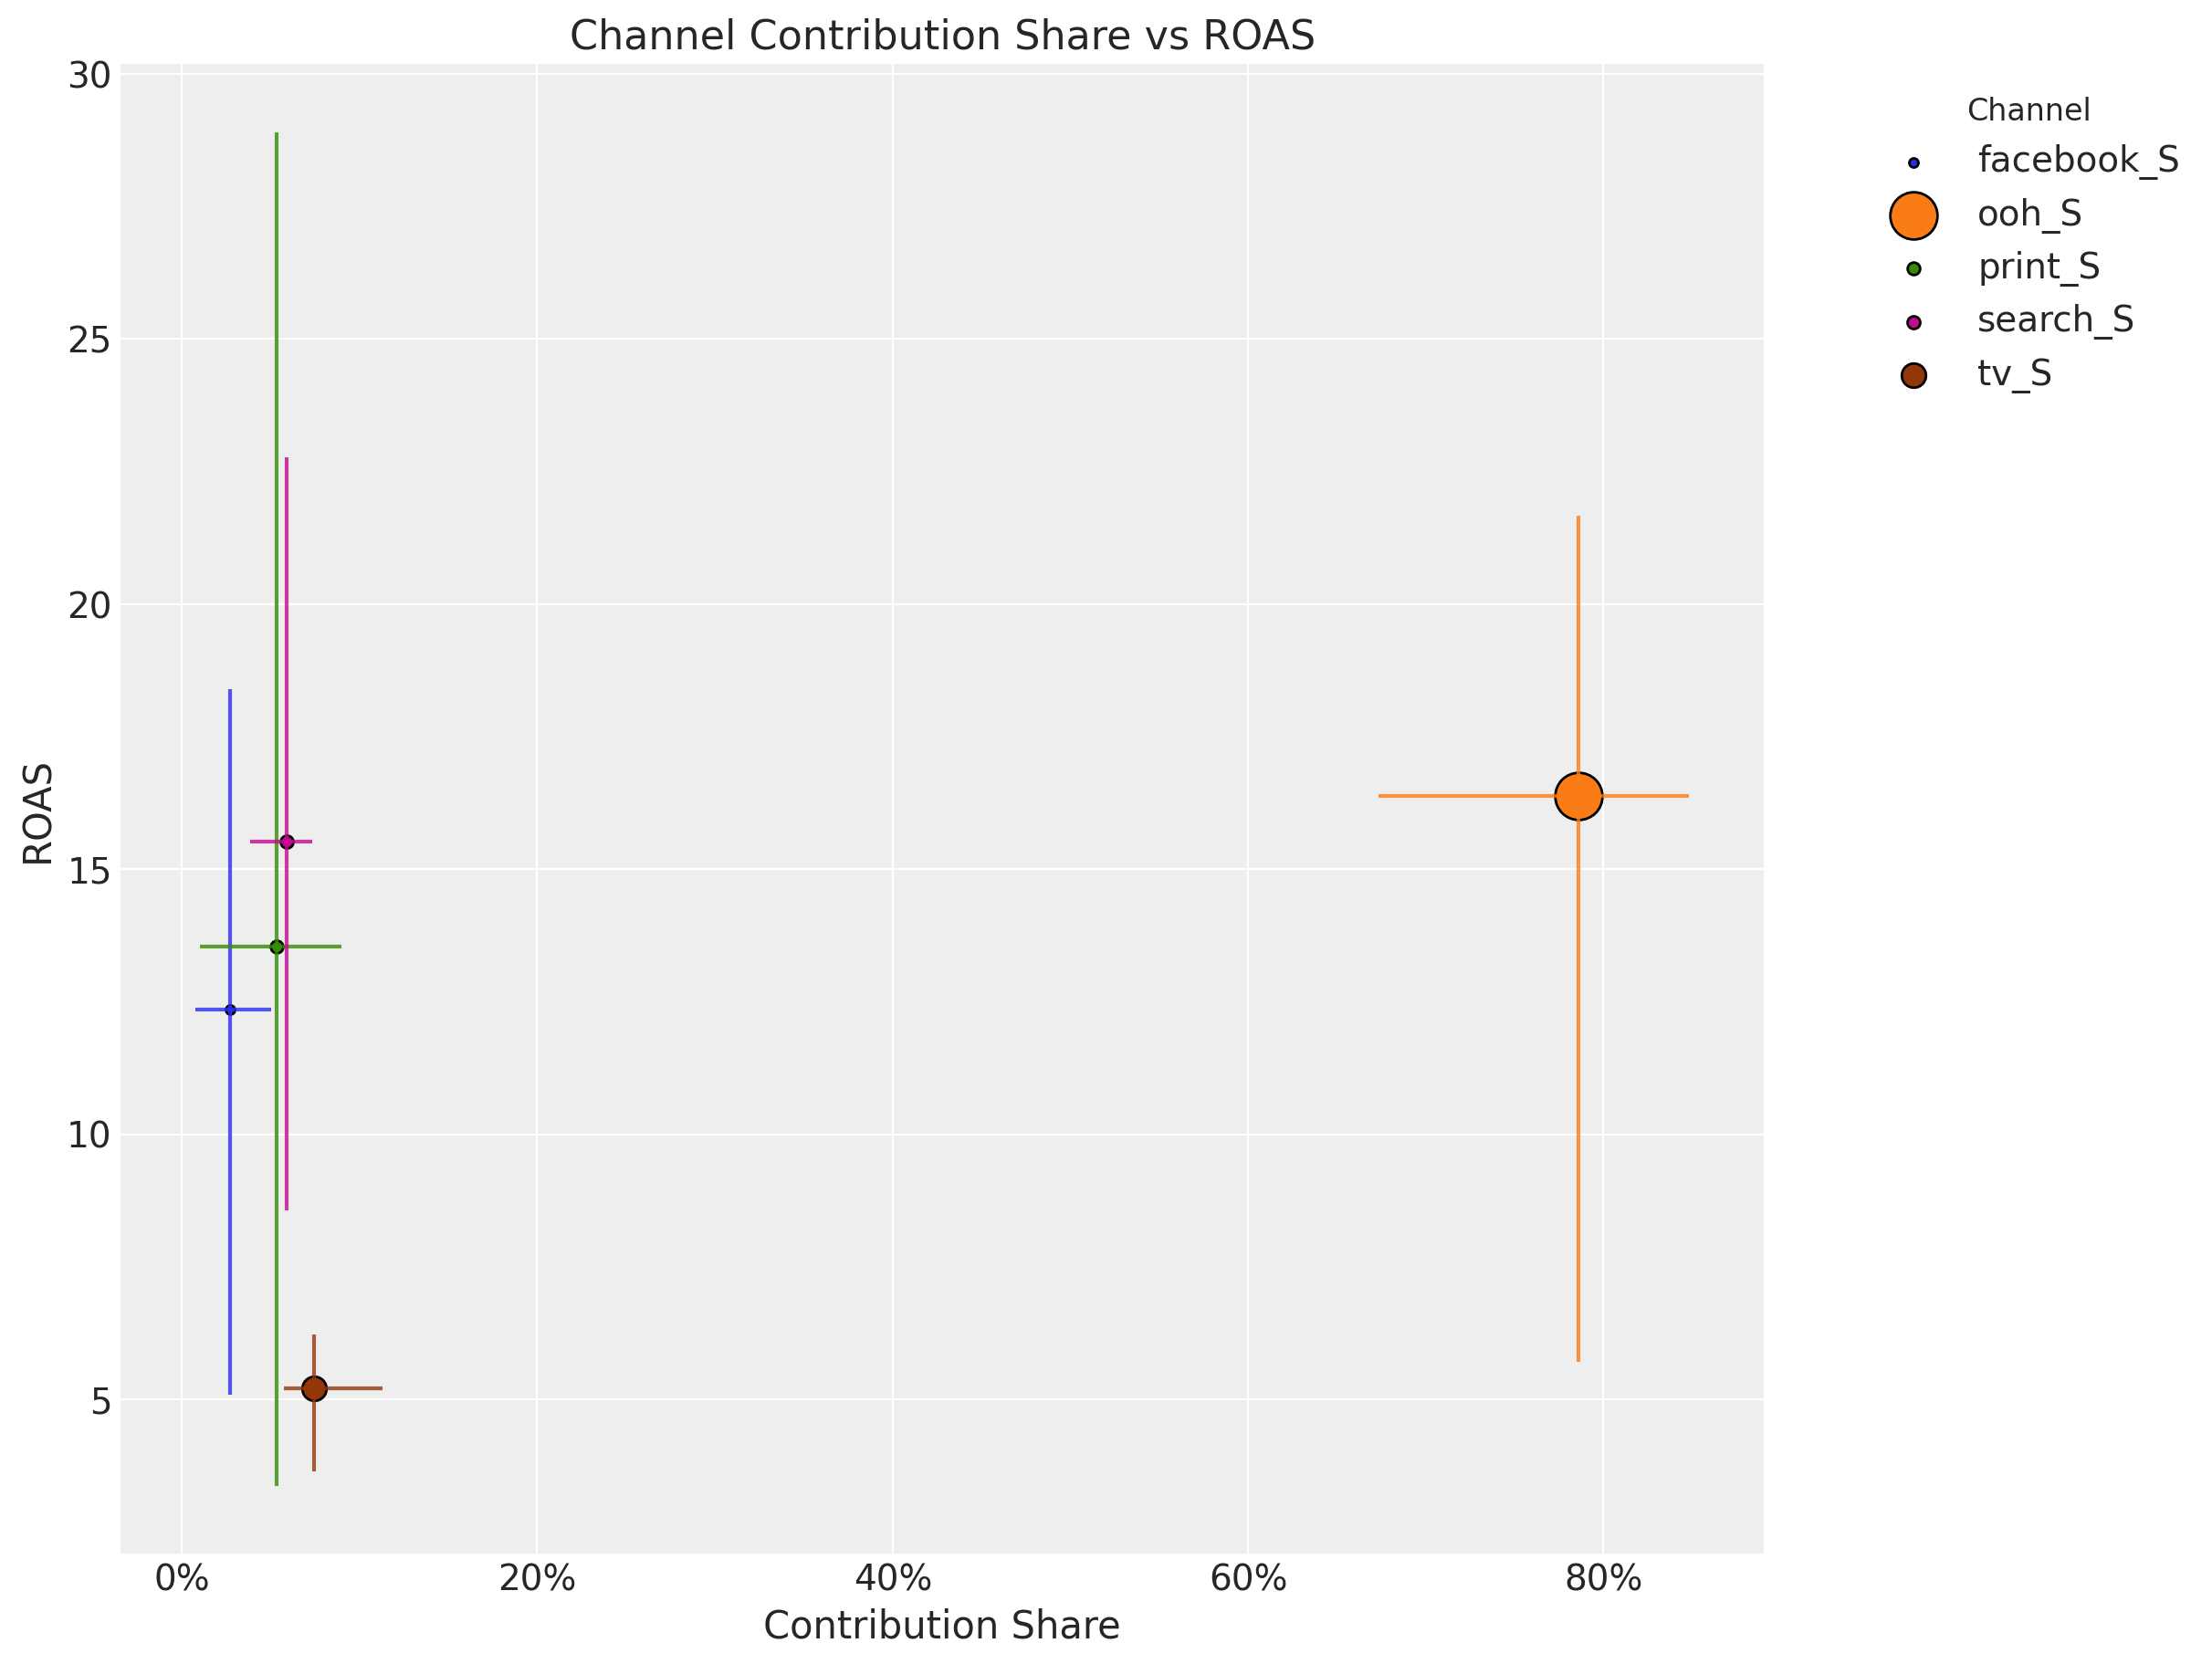

In [ ]:
# Get the contribution share samples
share_samples = mmm.get_channel_contribution_share_samples()

fig, ax = plt.subplots(figsize=(12, 9))

for i, channel in enumerate(channel_cols):
    # Contribution share mean and hdi
    share_mean = share_samples.sel(channel=channel).mean().to_numpy()
    share_hdi = az.hdi(share_samples.sel(channel=channel))["x"].to_numpy()

    # ROAS mean and hdi
    roas_mean = roas_samples.sel(channel=channel).mean().to_numpy()
    roas_hdi = az.hdi(roas_samples.sel(channel=channel))["x"].to_numpy()

    # Plot the contribution share hdi
    ax.vlines(share_mean, roas_hdi[0], roas_hdi[1], color=f"C{i}", alpha=0.8)

    # Plot the ROAS hdi
    ax.hlines(roas_mean, share_hdi[0], share_hdi[1], color=f"C{i}", alpha=0.8)

    # Plot the means
    ax.scatter(
        share_mean,
        roas_mean,
        # Size of the scatter points is proportional to the spend share
        s=5 * (prior_sigma[i] * 100),
        color=f"C{i}",
        edgecolor="black",
        label=channel,
    )
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

ax.legend(
    bbox_to_anchor=(1.05, 1), loc="upper left", title="Channel", title_fontsize=12
)
ax.set(
    title="Channel Contribution Share vs ROAS",
    xlabel="Contribution Share",
    ylabel="ROAS",
);

# 10. Out-of-Sample Predictions

In [43]:
y_pred_test = mmm.sample_posterior_predictive(
    X_test,
    include_last_observations=True,
    original_scale=True,
    var_names=["y", "channel_contribution"],
    extend_idata=False,
    progressbar=False,
    random_seed=1,
)

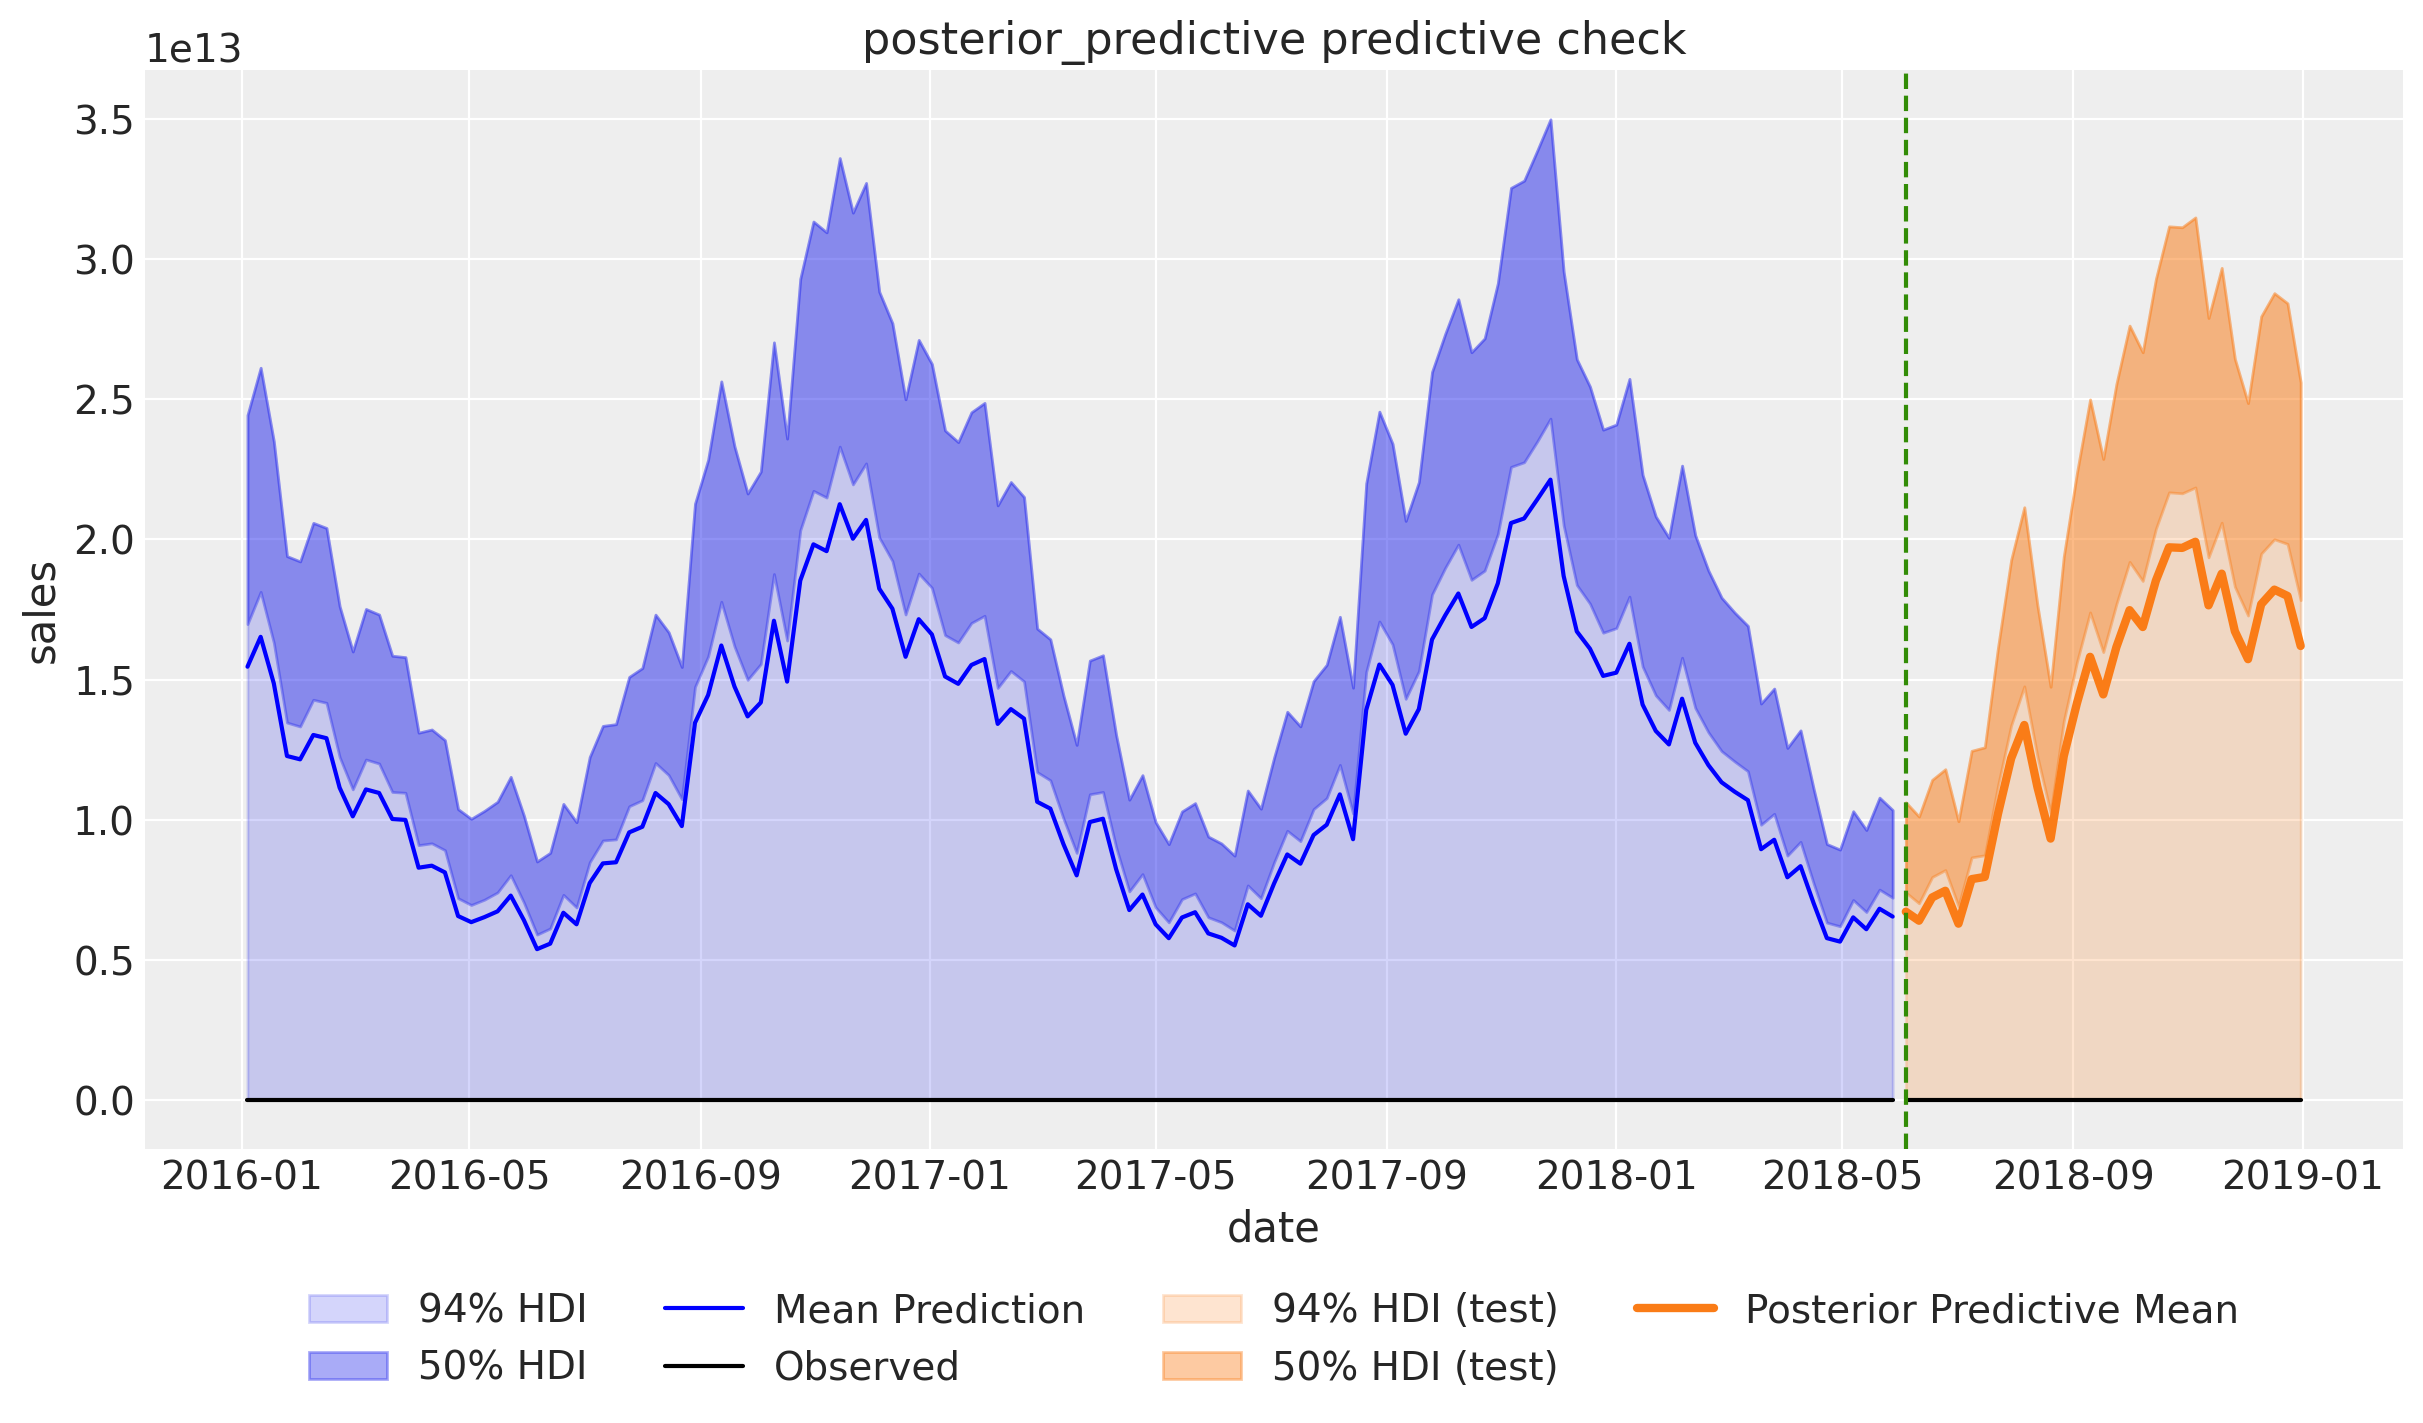

In [45]:
fig, ax = plt.subplots()
mmm.plot_posterior_predictive(original_scale=True, ax=ax)

test_hdi_94 = az.hdi(y_pred_test["y"].to_numpy().T, hdi_prob=0.94)
test_hdi_50 = az.hdi(y_pred_test["y"].to_numpy().T, hdi_prob=0.50)

ax.fill_between(
    X_test[date_col],
    test_hdi_94[:, 0],
    test_hdi_94[:, 1],
    color="C1",
    label=f"{0.94:.0%} HDI (test)",
    alpha=0.2,
)

ax.fill_between(
    X_test[date_col],
    test_hdi_50[:, 0],
    test_hdi_50[:, 1],
    color="C1",
    label=f"{0.50:.0%} HDI (test)",
    alpha=0.4,
)

ax.plot(X_test[date_col], y_test, color="black")
ax.plot(
    X_test[date_col],
    y_pred_test["y"].mean(dim="sample"),
    color="C1",
    linewidth=3,
    label="Posterior Predictive Mean",
)
ax.axvline(X_test[date_col].iloc[0], color="C2", linestyle="--")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=4)
ax.set(ylabel="sales");

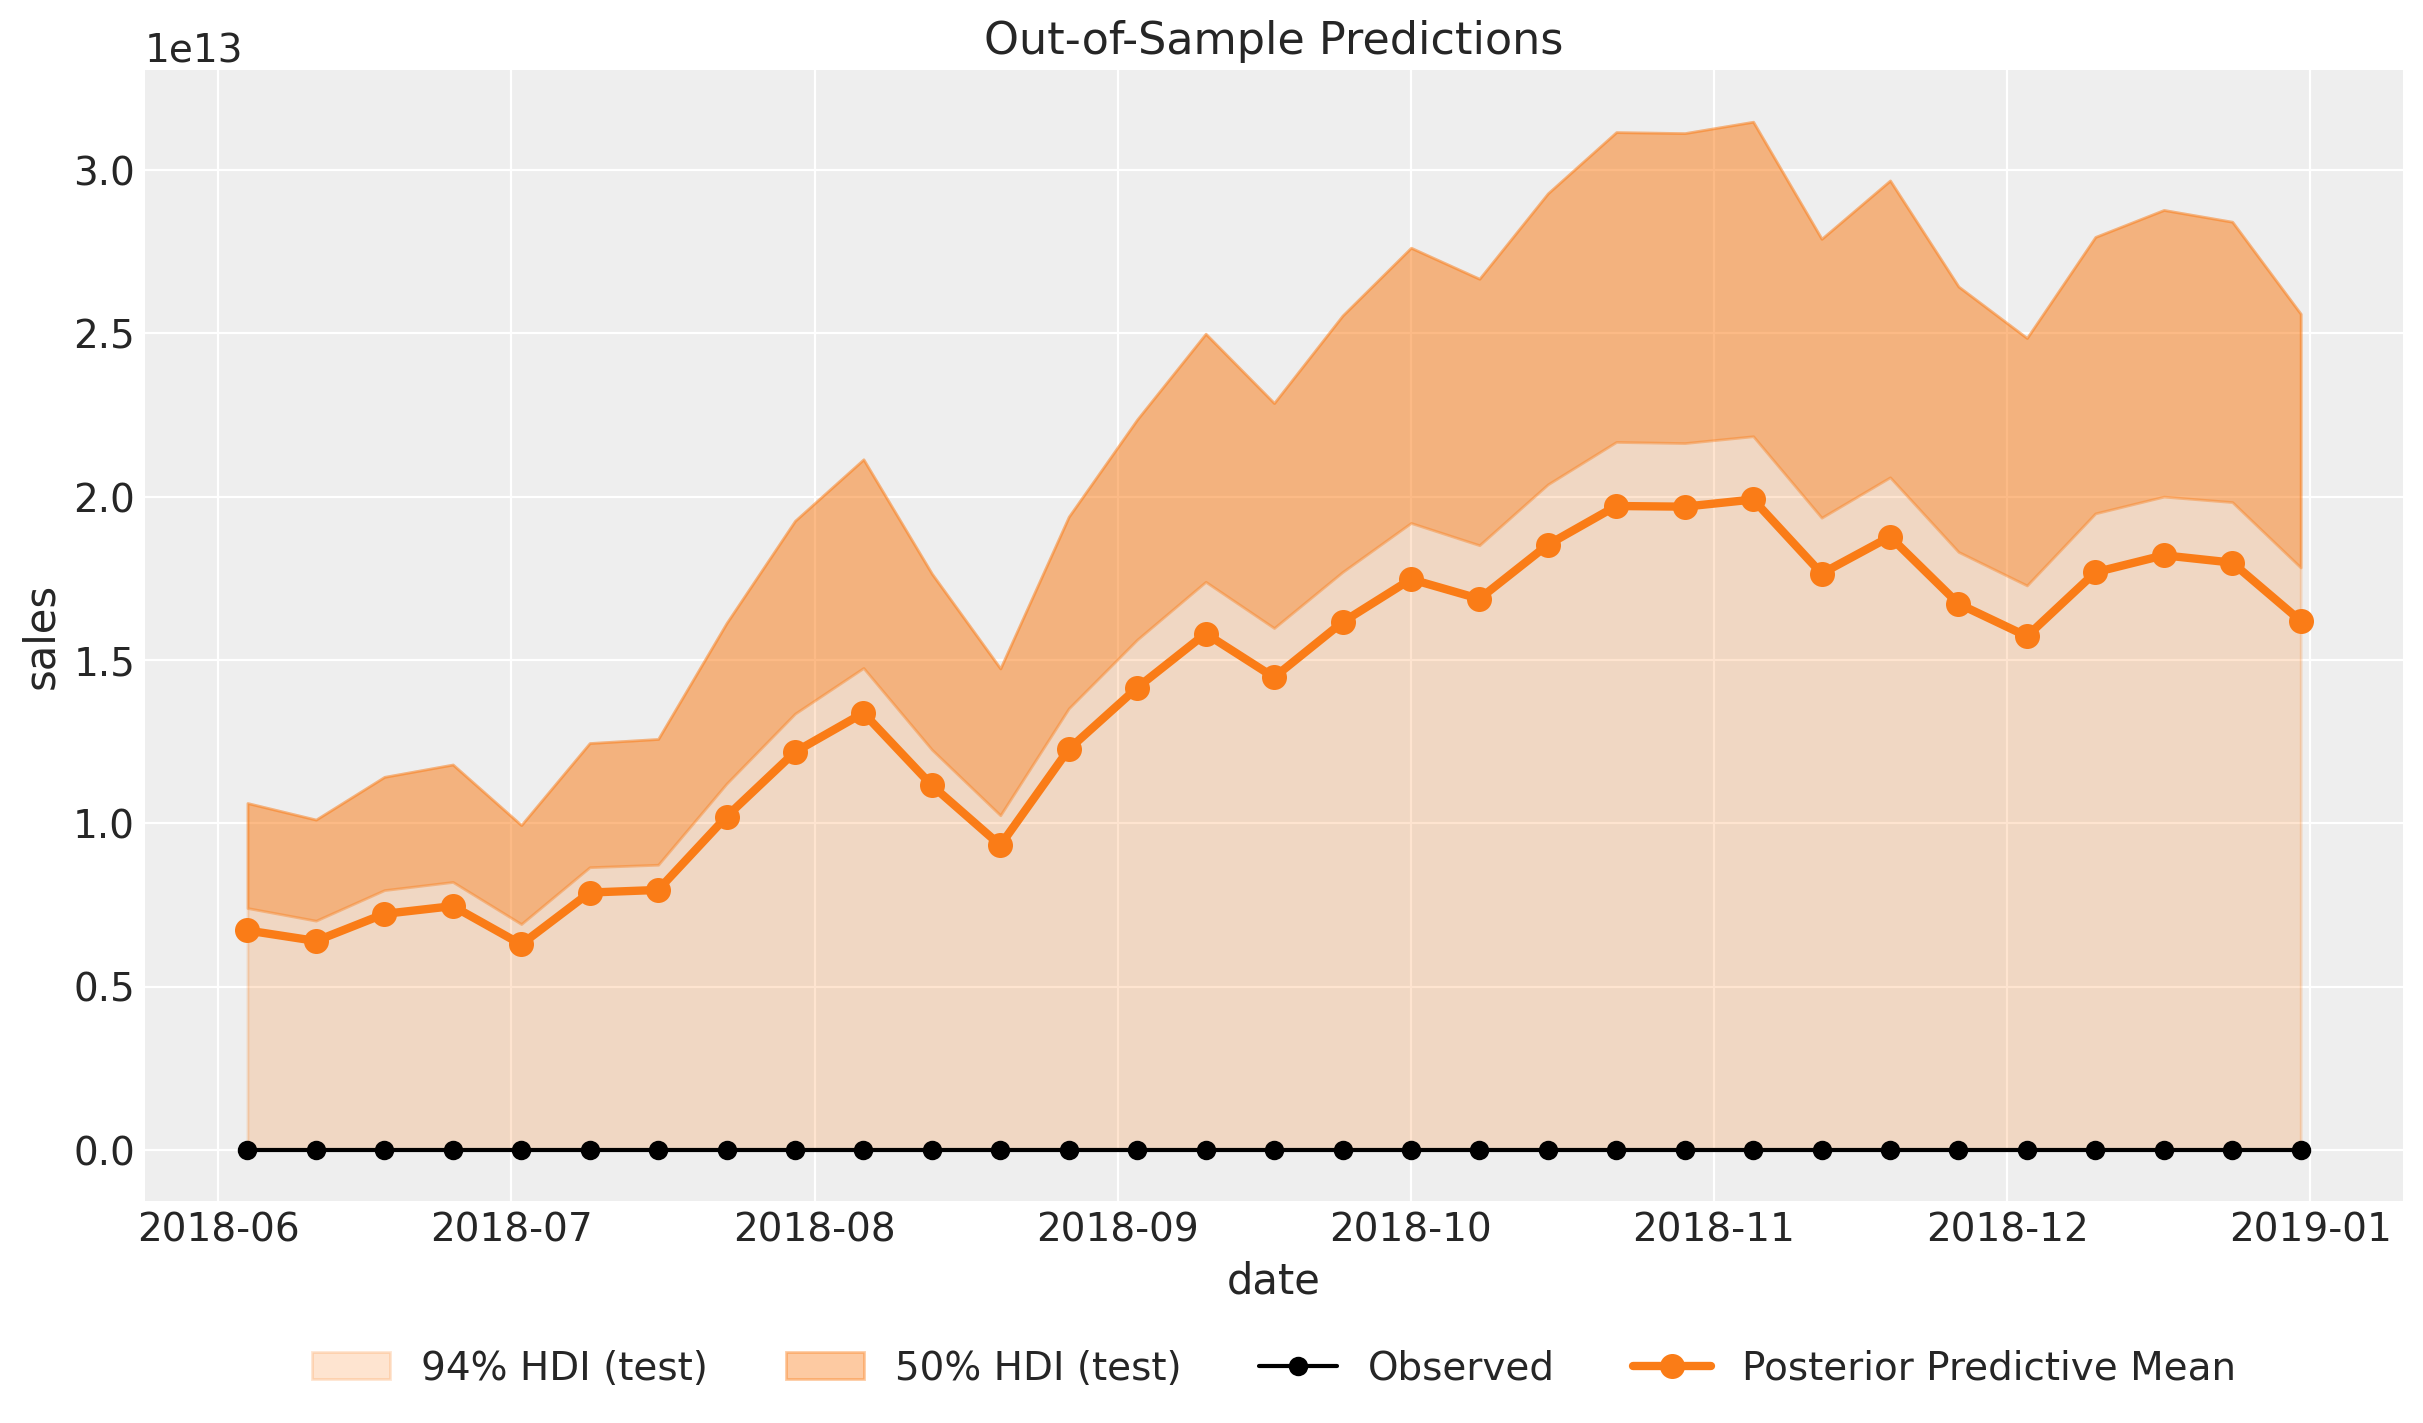

In [47]:
fig, ax = plt.subplots()
ax.fill_between(
    X_test[date_col],
    test_hdi_94[:, 0],
    test_hdi_94[:, 1],
    color="C1",
    label=f"{0.94:.0%} HDI (test)",
    alpha=0.2,
)
ax.fill_between(
    X_test[date_col],
    test_hdi_50[:, 0],
    test_hdi_50[:, 1],
    color="C1",
    label=f"{0.50:.0%} HDI (test)",
    alpha=0.4,
)
ax.plot(X_test[date_col], y_test, marker="o", color="black", label="Observed")
ax.plot(
    X_test[date_col],
    y_pred_test["y"].mean(dim="sample"),
    marker="o",
    markersize=8,
    color="C1",
    linewidth=3,
    label="Posterior Predictive Mean",
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=4)
ax.set(title="Out-of-Sample Predictions", xlabel="date", ylabel="sales");